# Threads of Evidence

**Team Members:** Japji Batra and Bushra Naveed

## Project Description

Threads of Evidence classifies fabric images into six categories:

- Acrylic
- Cotton
- Denim
- Silk
- Velvet
- Wool

The project uses the Fabrics Dataset by iBUG. Images of fabric samples were captured under multiple illumination conditions using a photometric stereo sensor.

## Project Workflow

1. Load the dataset
2. Perform exploratory data analysis
3. Preprocess and split the data
4. Extract features using pretrained ResNet50
5. Train a K-Nearest Neighbors baseline
6. Train additional preliminary models
7. Evaluate the models using accuracy, precision, recall, macro F1-score, and confusion matrices
8. Loss and Optimization
9. Tuning and Regularization
10. Error Analysis and Insight
11. Use Cloud

In [2]:
!pip install -q kagglehub

In [3]:
# Standard Python libraries
import random
import time
from pathlib import Path
from collections import Counter

# Data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Random seed: {SEED}")
print("Setup complete!")

PyTorch version: 2.11.0+cpu
Device: cpu
Random seed: 42
Setup complete!


## Step 1: Load the Dataset



In [4]:
import kagglehub

downloaded_path = Path(
    kagglehub.dataset_download(
        "orchit/the-fabrics-dataset-by-ibug",
        output_dir="/content/fabrics_dataset",
    )
)

print("KaggleHub returned:", downloaded_path)
print("Downloaded path exists:", downloaded_path.exists())

100%|██████████| 1.77G/1.77G [00:31<00:00, 60.4MB/s]

Extracting files...


KaggleHub returned: /content/fabrics_dataset
Downloaded path exists: True


In [5]:
SELECTED_CLASSES = [
    "Acrylic",
    "Cotton",
    "Denim",
    "Silk",
    "Velvet",
    "Wool"
]


def find_dataset_root(start_path, required_classes):
    """
    Locate a directory containing all required class folders.
    """

    start_path = Path(start_path)

    # Case 1: class folders are directly inside the returned path
    if all(
        (start_path / class_name).is_dir()
        for class_name in required_classes
    ):
        return start_path

    # Case 2: class folders are inside a nested directory
    for candidate in start_path.rglob("*"):
        if not candidate.is_dir():
            continue

        if all(
            (candidate / class_name).is_dir()
            for class_name in required_classes
        ):
            return candidate

    raise FileNotFoundError(
        "Could not find a folder containing all selected fabric classes."
    )


dataset_root = find_dataset_root(
    downloaded_path,
    SELECTED_CLASSES
)

classes = sorted(SELECTED_CLASSES)

print("Dataset root:", dataset_root)
print("Dataset exists:", dataset_root.exists())
print("Selected classes:", classes)
print("Number of selected classes:", len(classes))

Dataset root: /content/fabrics_dataset
Dataset exists: True
Selected classes: ['Acrylic', 'Cotton', 'Denim', 'Silk', 'Velvet', 'Wool']
Number of selected classes: 6


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
for class_name in classes:
    class_path = dataset_root / class_name

    '''image_count = len(
        list(class_path.rglob("*.png"))
        + list(class_path.rglob("*.jpg"))
        + list(class_path.rglob("*.jpeg"))
    )'''

    image_count = len([
        file_path
        for file_path in class_path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in [".png", ".jpg", ".jpeg"]
    ])


    print(
        f"{class_name:10s} | "
        f"folder exists: {class_path.exists()} | "
        f"PNG images: {image_count}"
    )

Acrylic    | folder exists: True | PNG images: 48
Cotton     | folder exists: True | PNG images: 2352
Denim      | folder exists: True | PNG images: 648
Silk       | folder exists: True | PNG images: 200
Velvet     | folder exists: True | PNG images: 44
Wool       | folder exists: True | PNG images: 360


In [8]:
from collections import Counter

extension_counts = Counter(
    file_path.suffix.lower()
    for file_path in dataset_root.rglob("*")
    if file_path.is_file() and file_path.suffix
)

print("Extensions used in the dataset:")

for extension, count in extension_counts.most_common():
    print(f"{extension:10s} | {count} files")

extensions = sorted(extension_counts.keys())
print(extensions)

Extensions used in the dataset:
.png       | 7881 files
.txt       | 1969 files
.jpg       | 4 files
.complete  | 1 files
['.complete', '.jpg', '.png', '.txt']


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

image_extensions = {".png", ".jpg", ".jpeg"}

class_counts = []

# Loop through every fabric class folder
for class_path in dataset_root.iterdir():
    if not class_path.is_dir():
        continue

    image_count = sum(
        1
        for file_path in class_path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in image_extensions
    )

    # Count immediate subfolders representing physical samples
    sample_folders = [
        folder
        for folder in class_path.iterdir()
        if folder.is_dir()
    ]

    sample_count = len(sample_folders)

    images_per_sample = (
        image_count / sample_count
        if sample_count > 0
        else 0
    )

    class_counts.append({
        "class_name": class_path.name,
        "number_of_images": image_count,
        "number_of_samples": sample_count,
        "images_per_sample": images_per_sample
    })

class_summary = pd.DataFrame(class_counts)

class_summary = class_summary.sort_values(
    by="number_of_samples",
    ascending=False
).reset_index(drop=True)

print("Number of class folders:", len(class_summary))
print("Total number of images:", class_summary["number_of_images"].sum())
print("Total physical samples:", class_summary["number_of_samples"].sum())

display(class_summary)

Number of class folders: 26
Total number of images: 7885
Total physical samples: 1972


,class_name,number_of_images,number_of_samples,images_per_sample
0,Cotton,2352,588,4.000000
1,Blended,1645,411,4.002433
2,Polyester,904,226,4.000000
3,Denim,648,162,4.000000
4,Unclassified,492,123,4.000000
5,Wool,360,90,4.000000
6,Nylon,228,57,4.000000
7,Silk,200,50,4.000000
8,Viscose,148,37,4.000000
9,Fleece,132,33,4.000000


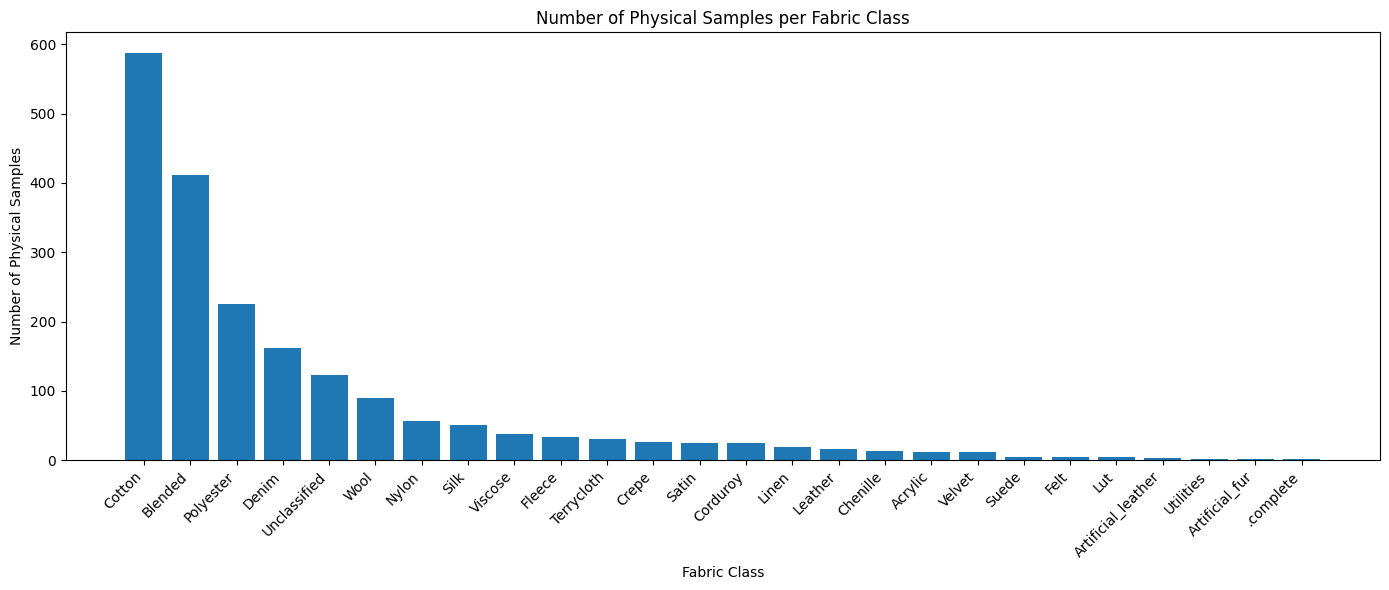

In [10]:
plt.figure(figsize=(14, 6))

plt.bar(
    class_summary["class_name"],
    class_summary["number_of_samples"]
)

plt.title("Number of Physical Samples per Fabric Class")
plt.xlabel("Fabric Class")
plt.ylabel("Number of Physical Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 2: Exploratory Data Analysis

The exploratory analysis examines:

- Number of classes
- Number of physical fabric samples
- Number of images per class
- Dataset imbalance
- Image dimensions
- Image color modes
- Corrupted files
- Sample images
- Multiple illumination images from the same fabric sample

In [11]:
image_records = []

for class_name in classes:
    class_path = dataset_root / class_name

    for image_path in sorted(class_path.rglob("*.png")):
        # The parent directory represents the physical fabric sample
        sample_id = image_path.parent.name

        image_records.append({
            "class_name": class_name,
            "sample_id": sample_id,
            "sample_folder": str(image_path.parent),
            "image_name": image_path.name,
            "image_path": str(image_path)
        })

metadata_df = pd.DataFrame(image_records)

print("Metadata shape:", metadata_df.shape)
print("Total images:", len(metadata_df))
print("Number of classes:", metadata_df["class_name"].nunique())

display(metadata_df.head())

Metadata shape: (3652, 5)
Total images: 3652
Number of classes: 6


,class_name,sample_id,sample_folder,image_name,image_path
0,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_1.png,/content/fabrics_dataset/Acrylic/182/im_1.png
1,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_2.png,/content/fabrics_dataset/Acrylic/182/im_2.png
2,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_3.png,/content/fabrics_dataset/Acrylic/182/im_3.png
3,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_4.png,/content/fabrics_dataset/Acrylic/182/im_4.png
4,Acrylic,183,/content/fabrics_dataset/Acrylic/183,im_1.png,/content/fabrics_dataset/Acrylic/183/im_1.png


In [12]:
#image count per class
images_per_class = (
    metadata_df
    .groupby("class_name")
    .size()
    .reset_index(name="number_of_images")
    .sort_values("class_name")
)

display(images_per_class)

print(
    "Total images:",
    images_per_class["number_of_images"].sum()
)

,class_name,number_of_images
0,Acrylic,48
1,Cotton,2352
2,Denim,648
3,Silk,200
4,Velvet,44
5,Wool,360


Total images: 3652


In [13]:
#sample per class
samples_per_class = (
    metadata_df[
        ["class_name", "sample_folder"]
    ]
    .drop_duplicates()
    .groupby("class_name")
    .size()
    .reset_index(name="number_of_samples")
    .sort_values("class_name")
)

display(samples_per_class)

print(
    "Total unique physical samples:",
    samples_per_class["number_of_samples"].sum()
)

,class_name,number_of_samples
0,Acrylic,12
1,Cotton,588
2,Denim,162
3,Silk,50
4,Velvet,11
5,Wool,90


Total unique physical samples: 913


In [14]:
class_summary = images_per_class.merge(
    samples_per_class,
    on="class_name"
)

class_summary["images_per_sample"] = (
    class_summary["number_of_images"]
    / class_summary["number_of_samples"]
)

display(class_summary)

,class_name,number_of_images,number_of_samples,images_per_sample
0,Acrylic,48,12,4.0
1,Cotton,2352,588,4.0
2,Denim,648,162,4.0
3,Silk,200,50,4.0
4,Velvet,44,11,4.0
5,Wool,360,90,4.0


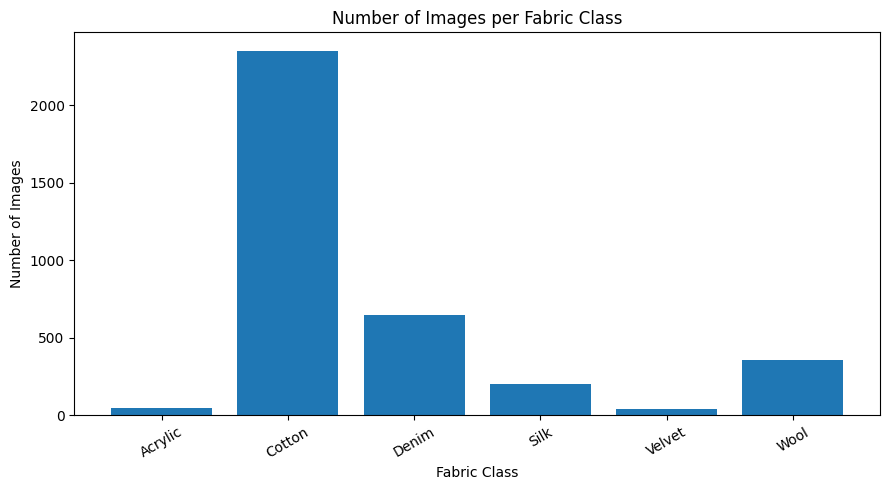

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    images_per_class["class_name"],
    images_per_class["number_of_images"]
)

plt.title("Number of Images per Fabric Class")
plt.xlabel("Fabric Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
size_counts = Counter()
mode_counts = Counter()
corrupted_images = []

for image_path in metadata_df["image_path"]:
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as image:
            size_counts[image.size] += 1
            mode_counts[image.mode] += 1

            # Force the image data to be read
            image.load()

    except Exception as error:
        corrupted_images.append({
            "image_path": str(image_path),
            "error": str(error)
        })

print("Image dimensions:")
for size, count in size_counts.most_common():
    print(f"  {size}: {count} images")

print("\nImage modes:")
for mode, count in mode_counts.most_common():
    print(f"  {mode}: {count} images")

print("\nCorrupted or unreadable images:", len(corrupted_images))

Image dimensions:
  (400, 400): 3652 images

Image modes:
  RGB: 3652 images

Corrupted or unreadable images: 0


In [17]:
image_property_rows = []

for image_path in metadata_df["image_path"]:
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as image:
            width, height = image.size

            image_property_rows.append({
                "image_path": str(image_path),
                "width": width,
                "height": height,
                "mode": image.mode
            })

    except Exception:
        continue

image_properties_df = pd.DataFrame(image_property_rows)

display(image_properties_df.describe(include="all"))

,image_path,width,height,mode
count,3652,3652.0,3652.0,3652
unique,3652,NaN,NaN,1
top,/content/fabrics_dataset/Wool/988/im_4.png,NaN,NaN,RGB
freq,1,NaN,NaN,3652
mean,NaN,400.0,400.0,NaN
std,NaN,0.0,0.0,NaN
min,NaN,400.0,400.0,NaN
25%,NaN,400.0,400.0,NaN
50%,NaN,400.0,400.0,NaN
75%,NaN,400.0,400.0,NaN


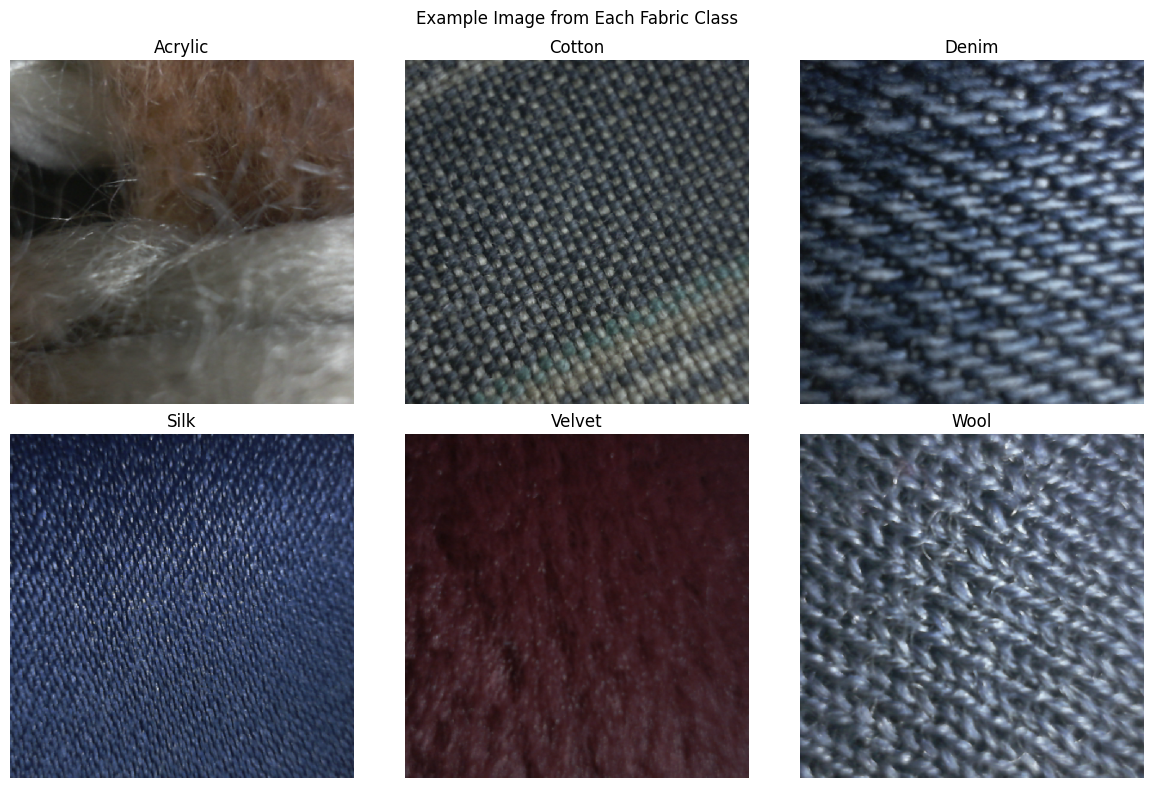

In [18]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, class_name in zip(
    axes.flatten(),
    classes
):
    class_images = metadata_df[
        metadata_df["class_name"] == class_name
    ]

    image_path = Path(
        class_images.iloc[0]["image_path"]
    )

    with Image.open(image_path) as image:
        ax.imshow(image.convert("RGB"))

    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("Example Image from Each Fabric Class")
plt.tight_layout()
plt.show()

In [19]:
IMAGES_PER_CLASS = 3

fig, axes = plt.subplots(
    len(classes),
    IMAGES_PER_CLASS,
    figsize=(12, 3 * len(classes))
)

for row_index, class_name in enumerate(classes):
    class_images = metadata_df[
        metadata_df["class_name"] == class_name
    ]

    sampled_rows = class_images.sample(
        n=min(IMAGES_PER_CLASS, len(class_images)),
        random_state=SEED
    )

    for column_index in range(IMAGES_PER_CLASS):
        ax = axes[row_index, column_index]

        if column_index >= len(sampled_rows):
            ax.axis("off")
            continue

        row = sampled_rows.iloc[column_index]
        image_path = Path(row["image_path"])

        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f"{class_name}\n{image_path.name}"
        )
        ax.axis("off")

plt.suptitle("Random Fabric Examples")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Class: Cotton
Sample folder: /content/fabrics_dataset/Cotton/10
Number of images: 4


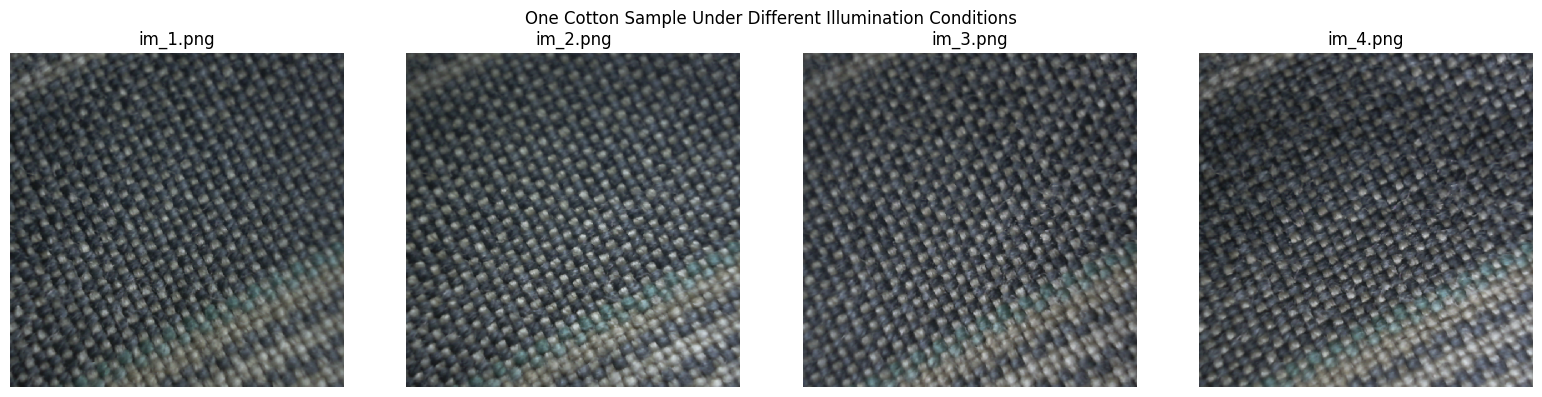

In [20]:
example_class = "Cotton"

example_class_df = metadata_df[
    metadata_df["class_name"] == example_class
]

example_sample_folder = (
    example_class_df
    .iloc[0]["sample_folder"]
)

illumination_images = sorted(
    Path(example_sample_folder).glob("*.png")
)

print("Class:", example_class)
print("Sample folder:", example_sample_folder)
print("Number of images:", len(illumination_images))

fig, axes = plt.subplots(
    1,
    len(illumination_images),
    figsize=(4 * len(illumination_images), 4)
)

if len(illumination_images) == 1:
    axes = [axes]

for ax, image_path in zip(
    axes,
    illumination_images
):
    with Image.open(image_path) as image:
        ax.imshow(image.convert("RGB"))

    ax.set_title(image_path.name)
    ax.axis("off")

plt.suptitle(
    f"One {example_class} Sample Under Different Illumination Conditions"
)
plt.tight_layout()
plt.show()

### EDA Findings

The selected dataset contains six fabric classes: Acrylic, Cotton, Denim, Silk, Velvet, and Wool. The dataset contains **3652 images** representing **913 unique physical fabric samples**.

Each physical sample is stored in a numbered subfolder and was photographed under multiple illumination conditions. Therefore, several images may represent the same physical garment or fabric sample.

The class-distribution plots show that the dataset is **not balanced**. All or most images have a resolution of **400x400** and use **RGB** color. The corrupted-image check found **0** unreadable files.

## Step 3: Preprocessing

The preprocessing pipeline:

1. Keeps images in RGB format
2. Resizes images to 224 × 224 pixels
3. Converts images to PyTorch tensors
4. Normalizes images using ImageNet statistics
5. Splits the data by physical sample folder
6. Prevents illumination images of the same physical sample from appearing in multiple data splits
7. Creates training, validation, and testing DataLoaders

In [21]:
#label encoding
class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Class mapping:")
print(class_to_idx)

Class mapping:
{'Acrylic': 0, 'Cotton': 1, 'Denim': 2, 'Silk': 3, 'Velvet': 4, 'Wool': 5}


In [22]:
sample_level_df = (
    metadata_df[
        ["class_name", "sample_folder"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

sample_level_df["label"] = (
    sample_level_df["class_name"]
    .map(class_to_idx)
)

print("Sample-level table shape:", sample_level_df.shape)

display(sample_level_df)

Sample-level table shape: (913, 3)


,class_name,sample_folder,label
0,Acrylic,/content/fabrics_dataset/Acrylic/182,0
1,Acrylic,/content/fabrics_dataset/Acrylic/183,0
2,Acrylic,/content/fabrics_dataset/Acrylic/184,0
3,Acrylic,/content/fabrics_dataset/Acrylic/328,0
4,Acrylic,/content/fabrics_dataset/Acrylic/329,0
...,...,...,...
908,Wool,/content/fabrics_dataset/Wool/984,5
909,Wool,/content/fabrics_dataset/Wool/985,5
910,Wool,/content/fabrics_dataset/Wool/986,5
911,Wool,/content/fabrics_dataset/Wool/987,5


In [23]:
train_samples, temporary_samples = train_test_split(
    sample_level_df,
    test_size=0.30,
    random_state=SEED,
    stratify=sample_level_df["class_name"]
)

validation_samples, test_samples = train_test_split(
    temporary_samples,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_samples["class_name"]
)

train_samples = train_samples.reset_index(drop=True)
validation_samples = validation_samples.reset_index(drop=True)
test_samples = test_samples.reset_index(drop=True)

print("Physical sample split:")
print(f"Training samples:   {len(train_samples):,}")
print(f"Validation samples: {len(validation_samples):,}")
print(f"Testing samples:    {len(test_samples):,}")

Physical sample split:
Training samples:   639
Validation samples: 137
Testing samples:    137


In [24]:
# verify no sample overlapping

In [25]:
train_folders = set(train_samples["sample_folder"])
validation_folders = set(validation_samples["sample_folder"])
test_folders = set(test_samples["sample_folder"])

print(
    "Train-validation overlap:",
    len(train_folders & validation_folders)
)

print(
    "Train-test overlap:",
    len(train_folders & test_folders)
)

print(
    "Validation-test overlap:",
    len(validation_folders & test_folders)
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [26]:
def select_images_from_sample_split(
    full_metadata,
    split_samples
):
    allowed_folders = set(
        split_samples["sample_folder"]
    )

    split_images = full_metadata[
        full_metadata["sample_folder"].isin(
            allowed_folders
        )
    ].copy()

    split_images["label"] = (
        split_images["class_name"]
        .map(class_to_idx)
    )

    return split_images.reset_index(drop=True)


train_images_df = select_images_from_sample_split(
    metadata_df,
    train_samples
)

validation_images_df = select_images_from_sample_split(
    metadata_df,
    validation_samples
)

test_images_df = select_images_from_sample_split(
    metadata_df,
    test_samples
)

print("Image split:")
print(f"Training images:   {len(train_images_df):,}")
print(f"Validation images: {len(validation_images_df):,}")
print(f"Testing images:    {len(test_images_df):,}")
train_images_df.head()

Image split:
Training images:   2,556
Validation images: 548
Testing images:    548


,class_name,sample_id,sample_folder,image_name,image_path,label
0,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_1.png,/content/fabrics_dataset/Acrylic/182/im_1.png,0
1,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_2.png,/content/fabrics_dataset/Acrylic/182/im_2.png,0
2,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_3.png,/content/fabrics_dataset/Acrylic/182/im_3.png,0
3,Acrylic,182,/content/fabrics_dataset/Acrylic/182,im_4.png,/content/fabrics_dataset/Acrylic/182/im_4.png,0
4,Acrylic,183,/content/fabrics_dataset/Acrylic/183,im_1.png,/content/fabrics_dataset/Acrylic/183/im_1.png,0


In [27]:
def count_split_classes(split_df, column_name):
    return (
        split_df
        .groupby("class_name")
        .size()
        .reset_index(name=column_name)
    )


train_distribution = count_split_classes(
    train_images_df,
    "train_images"
)

validation_distribution = count_split_classes(
    validation_images_df,
    "validation_images"
)

test_distribution = count_split_classes(
    test_images_df,
    "test_images"
)

split_distribution = (
    train_distribution
    .merge(
        validation_distribution,
        on="class_name",
        how="outer"
    )
    .merge(
        test_distribution,
        on="class_name",
        how="outer"
    )
    .fillna(0)
)

display(split_distribution)

,class_name,train_images,validation_images,test_images
0,Acrylic,32,8,8
1,Cotton,1648,352,352
2,Denim,452,96,100
3,Silk,140,32,28
4,Velvet,32,4,8
5,Wool,252,56,52


In [28]:
IMAGE_SIZE = 224

# Training transformation includes light augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and testing should not use random augmentation
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformation:")
print(train_transform)

print("\nEvaluation transformation:")
print(evaluation_transform)

Training transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [29]:
# custom fabric dataset
class FabricDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        label = int(row["label"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [30]:
train_dataset = FabricDataset(
    train_images_df,
    transform=train_transform
)

validation_dataset = FabricDataset(
    validation_images_df,
    transform=evaluation_transform
)

test_dataset = FabricDataset(
    test_images_df,
    transform=evaluation_transform
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(validation_dataset):,}")
print(f"Testing samples:    {len(test_dataset):,}")

Training samples:   2,556
Validation samples: 548
Testing samples:    548


In [31]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Batch size:         {BATCH_SIZE}")
print(f"Training batches:   {len(train_loader):,}")
print(f"Validation batches: {len(validation_loader):,}")
print(f"Testing batches:    {len(test_loader):,}")

Batch size:         32
Training batches:   80
Validation batches: 18
Testing batches:    18


In [32]:
#inspect one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("First ten labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
First ten labels: tensor([1, 5, 2, 1, 5, 1, 2, 1, 1, 2])


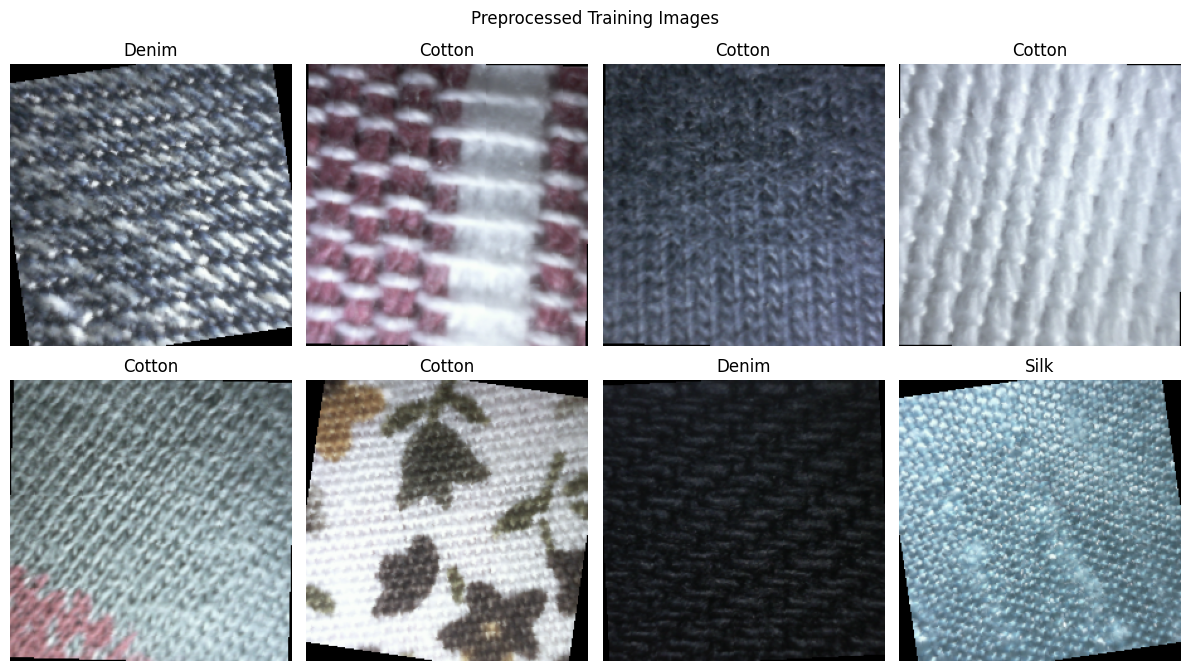

In [33]:
#display preprocessed images

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image_tensor):
    image_tensor = image_tensor.cpu()
    image_tensor = (
        image_tensor * IMAGENET_STD
        + IMAGENET_MEAN
    )

    return image_tensor.clamp(0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7)
)

for index, ax in enumerate(axes.flatten()):
    image = denormalize_image(images[index])

    image = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    label = labels[index].item()

    ax.imshow(image)
    ax.set_title(idx_to_class[label])
    ax.axis("off")

plt.suptitle("Preprocessed Training Images")
plt.tight_layout()
plt.show()

## Baseline and Preliminary Models

We used a pretrained ResNet50 model as a feature extractor. The final classification layer was removed, producing a 2,048-dimensional embedding for each image.

K-Nearest Neighbors was used as the baseline model. Logistic Regression and Random Forest were trained as preliminary comparison models.

In [43]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

feature_extractor = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet50 feature extractor ready.")

ResNet50 feature extractor ready.


In [44]:
from tqdm.auto import tqdm
import numpy as np
import torch


def extract_features(model, data_loader, device, description="Extracting features"):
    model.eval()

    all_features = []
    all_labels = []

    progress_bar = tqdm(
        data_loader,
        desc=description,
        total=len(data_loader),
        unit="batch"
    )

    with torch.inference_mode():
        for images, labels in progress_bar:
            images = images.to(
                device,
                non_blocking=True
            )

            features = model(images)
            features = torch.flatten(features, start_dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

            progress_bar.set_postfix(
                batch_size=images.size(0),
                features=features.shape[1]
            )

    X = torch.cat(all_features, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()

    return X, y

In [45]:
X_train, y_train = extract_features(
    feature_extractor,
    train_loader,
    device,
    description="Training features"
)

X_validation, y_validation = extract_features(
    feature_extractor,
    validation_loader,
    device,
    description="Validation features"
)

X_test, y_test = extract_features(
    feature_extractor,
    test_loader,
    device,
    description="Testing features"
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features:   0%|          | 0/80 [00:00<?, ?batch/s]

Validation features:   0%|          | 0/18 [00:00<?, ?batch/s]

Testing features:   0%|          | 0/18 [00:00<?, ?batch/s]

Training features: (2556, 2048)
Testing features: (548, 2048)


In [46]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [47]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.8850,0.7148,0.8180,0.7439
0,KNN Baseline,0.8394,0.5527,0.4779,0.5020
2,Random Forest,0.8011,0.6077,0.3692,0.4064


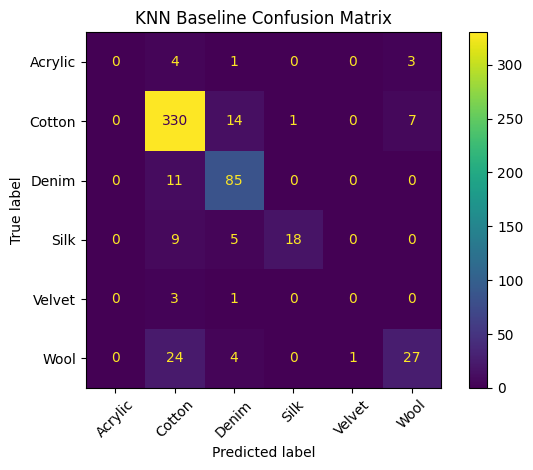

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=classes,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

Essentially, Acylic is getting completely ignored.  Velvet as well, due to severe class imbalance.

#Redoing Pipeline choosing different classes

In light of severe class imbalance, choosing to experiment with other classes that have more samples (and possibly have similar class size)



option: could moderately undersample Cotton and Blended;
retain most of Polyester and Denim;
mildly oversample Wool, Nylon, and Silk;
use light augmentation for smaller classes;

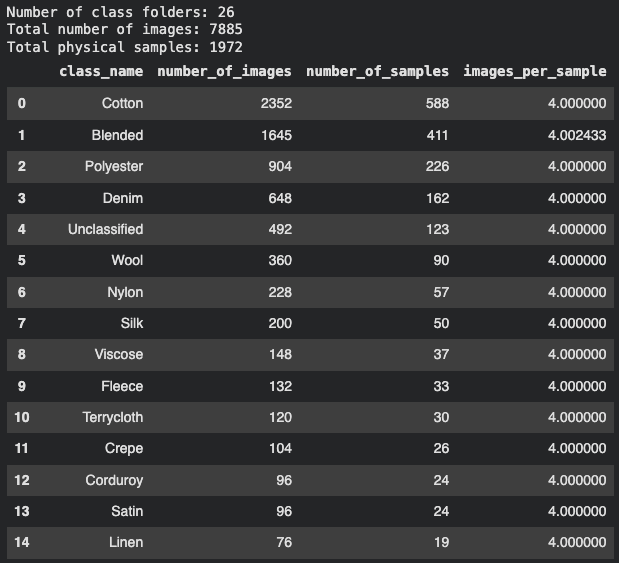

In [59]:
#ignore classes that
all_classes_to_consider = [
    "Cotton",
    "Polyester",
    "Denim",
    "Wool",
    "Nylon",
    "Silk",
    "Viscose",
    "Fleece",
    "Terrycloth",
    "Crepe",
    "Corduroy",
    "Satin",
    "Linen",
]

In [60]:
image_records = []
image_extensions = {".png", ".jpg", ".jpeg"}


for class_name in all_classes_to_consider:
    class_path = dataset_root / class_name

    for image_path in sorted(class_path.rglob("*")):
        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in image_extensions:
            continue

        # The parent directory represents the physical fabric sample
        sample_id = image_path.parent.name

        image_records.append({
            "class_name": class_name,
            "sample_id": sample_id,
            "sample_folder": str(image_path.parent),
            "image_name": image_path.name,
            "image_path": str(image_path)
        })

full_metadata_df = pd.DataFrame(image_records)

print("Metadata shape:", full_metadata_df.shape)
print("Total images:", len(full_metadata_df))
print("Number of classes:", full_metadata_df["class_name"].nunique())
print(
    "Number of physical samples:",
    full_metadata_df[
        ["class_name", "sample_id"]
    ].drop_duplicates().shape[0]
)


display(full_metadata_df)

Metadata shape: (5464, 5)
Total images: 5464
Number of classes: 13
Number of physical samples: 1366


,class_name,sample_id,sample_folder,image_name,image_path
0,Cotton,10,/content/fabrics_dataset/Cotton/10,im_1.png,/content/fabrics_dataset/Cotton/10/im_1.png
1,Cotton,10,/content/fabrics_dataset/Cotton/10,im_2.png,/content/fabrics_dataset/Cotton/10/im_2.png
2,Cotton,10,/content/fabrics_dataset/Cotton/10,im_3.png,/content/fabrics_dataset/Cotton/10/im_3.png
3,Cotton,10,/content/fabrics_dataset/Cotton/10,im_4.png,/content/fabrics_dataset/Cotton/10/im_4.png
4,Cotton,100,/content/fabrics_dataset/Cotton/100,im_1.png,/content/fabrics_dataset/Cotton/100/im_1.png
...,...,...,...,...,...
5459,Linen,800,/content/fabrics_dataset/Linen/800,im_4.png,/content/fabrics_dataset/Linen/800/im_4.png
5460,Linen,801,/content/fabrics_dataset/Linen/801,im_1.png,/content/fabrics_dataset/Linen/801/im_1.png
5461,Linen,801,/content/fabrics_dataset/Linen/801,im_2.png,/content/fabrics_dataset/Linen/801/im_2.png
5462,Linen,801,/content/fabrics_dataset/Linen/801,im_3.png,/content/fabrics_dataset/Linen/801/im_3.png


##Step 1: EDA

In [61]:
#image count per class
images_per_class = (
    full_metadata_df
    .groupby("class_name")
    .size()
    .reset_index(name="number_of_images")
    .sort_values("class_name")
)

display(images_per_class)

print(
    "Total images:",
    images_per_class["number_of_images"].sum()
)

,class_name,number_of_images
0,Corduroy,96
1,Cotton,2352
2,Crepe,104
3,Denim,648
4,Fleece,132
5,Linen,76
6,Nylon,228
7,Polyester,904
8,Satin,96
9,Silk,200


Total images: 5464


In [62]:
#sample per class
full_samples_per_class = (
    full_metadata_df[
        ["class_name", "sample_folder"]
    ]
    .drop_duplicates()
    .groupby("class_name")
    .size()
    .reset_index(name="number_of_samples")
    .sort_values("class_name")
)

display(full_samples_per_class)

print(
    "Total unique physical samples:",
    full_samples_per_class["number_of_samples"].sum()
)

,class_name,number_of_samples
0,Corduroy,24
1,Cotton,588
2,Crepe,26
3,Denim,162
4,Fleece,33
5,Linen,19
6,Nylon,57
7,Polyester,226
8,Satin,24
9,Silk,50


Total unique physical samples: 1366


In [63]:
class_summary = images_per_class.merge(
    full_samples_per_class,
    on="class_name"
)

class_summary["images_per_sample"] = (
    class_summary["number_of_images"]
    / class_summary["number_of_samples"]
)

display(class_summary)

,class_name,number_of_images,number_of_samples,images_per_sample
0,Corduroy,96,24,4.0
1,Cotton,2352,588,4.0
2,Crepe,104,26,4.0
3,Denim,648,162,4.0
4,Fleece,132,33,4.0
5,Linen,76,19,4.0
6,Nylon,228,57,4.0
7,Polyester,904,226,4.0
8,Satin,96,24,4.0
9,Silk,200,50,4.0


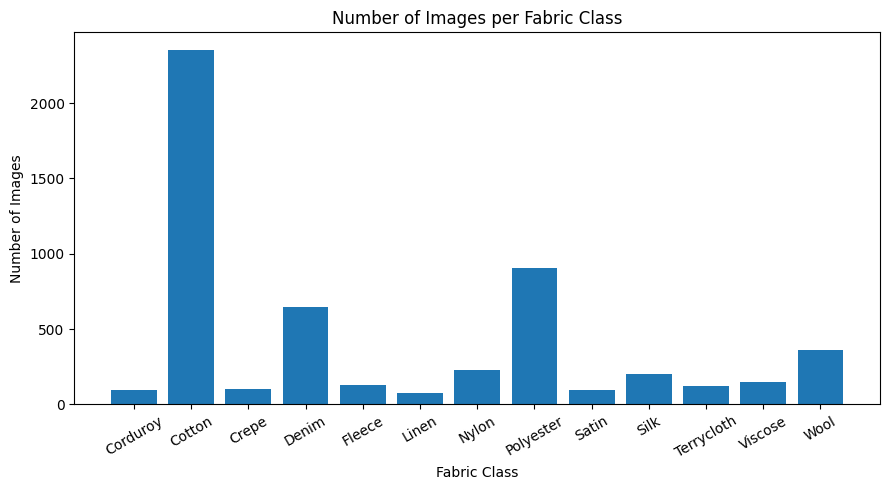

In [64]:
plt.figure(figsize=(9, 5))

plt.bar(
    images_per_class["class_name"],
    images_per_class["number_of_images"]
)

plt.title("Number of Images per Fabric Class")
plt.xlabel("Fabric Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [65]:
size_counts = Counter()
mode_counts = Counter()
corrupted_images = []

for image_path in full_metadata_df["image_path"]:
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as image:
            size_counts[image.size] += 1
            mode_counts[image.mode] += 1

            # Force the image data to be read
            image.load()

    except Exception as error:
        corrupted_images.append({
            "image_path": str(image_path),
            "error": str(error)
        })

print("Image dimensions:")
for size, count in size_counts.most_common():
    print(f"  {size}: {count} images")

print("\nImage modes:")
for mode, count in mode_counts.most_common():
    print(f"  {mode}: {count} images")

print("\nCorrupted or unreadable images:", len(corrupted_images))

Image dimensions:
  (400, 400): 5464 images

Image modes:
  RGB: 5464 images

Corrupted or unreadable images: 0


In [66]:
image_property_rows = []

for image_path in full_metadata_df["image_path"]:
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as image:
            width, height = image.size

            image_property_rows.append({
                "image_path": str(image_path),
                "width": width,
                "height": height,
                "mode": image.mode
            })

    except Exception:
        continue

full_image_properties_df = pd.DataFrame(image_property_rows)

display(full_image_properties_df.describe(include="all"))

,image_path,width,height,mode
count,5464,5464.0,5464.0,5464
unique,5464,NaN,NaN,1
top,/content/fabrics_dataset/Linen/801/im_4.png,NaN,NaN,RGB
freq,1,NaN,NaN,5464
mean,NaN,400.0,400.0,NaN
std,NaN,0.0,0.0,NaN
min,NaN,400.0,400.0,NaN
25%,NaN,400.0,400.0,NaN
50%,NaN,400.0,400.0,NaN
75%,NaN,400.0,400.0,NaN


In [70]:
IMAGES_PER_CLASS = 3

fig, axes = plt.subplots(
    len(all_classes_to_consider),
    IMAGES_PER_CLASS,
    figsize=(12, 3 * len(all_classes_to_consider))
)

for row_index, class_name in enumerate(all_classes_to_consider):
    class_images = full_metadata_df[
        full_metadata_df["class_name"] == class_name
    ]

    sampled_rows = class_images.sample(
        n=min(IMAGES_PER_CLASS, len(class_images)),
        random_state=SEED
    )

    for column_index in range(IMAGES_PER_CLASS):
        ax = axes[row_index, column_index]

        if column_index >= len(sampled_rows):
            ax.axis("off")
            continue

        row = sampled_rows.iloc[column_index]
        image_path = Path(row["image_path"])

        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f"{class_name}\n{image_path.name}"
        )
        ax.axis("off")

plt.suptitle("Random Fabric Examples")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Class: Cotton
Sample folder: /content/fabrics_dataset/Cotton/10
Number of images: 4


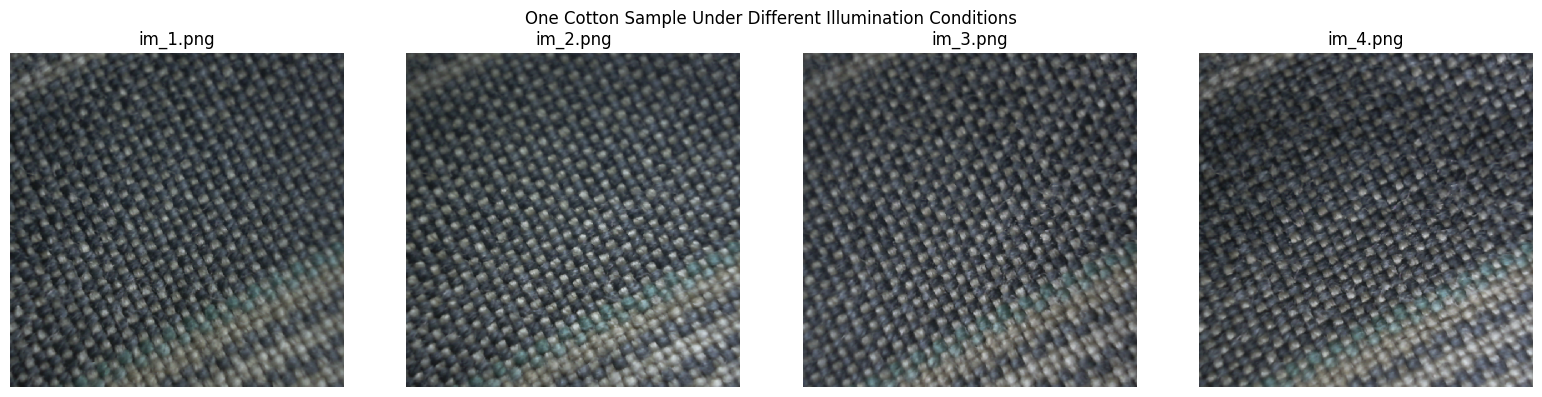

In [71]:
example_class = "Cotton"

example_class_df = full_metadata_df[
    full_metadata_df["class_name"] == example_class
]

example_sample_folder = (
    example_class_df
    .iloc[0]["sample_folder"]
)

illumination_images = sorted(
    Path(example_sample_folder).glob("*.png")
)

print("Class:", example_class)
print("Sample folder:", example_sample_folder)
print("Number of images:", len(illumination_images))

fig, axes = plt.subplots(
    1,
    len(illumination_images),
    figsize=(4 * len(illumination_images), 4)
)

if len(illumination_images) == 1:
    axes = [axes]

for ax, image_path in zip(
    axes,
    illumination_images
):
    with Image.open(image_path) as image:
        ax.imshow(image.convert("RGB"))

    ax.set_title(image_path.name)
    ax.axis("off")

plt.suptitle(
    f"One {example_class} Sample Under Different Illumination Conditions"
)
plt.tight_layout()
plt.show()

##Step 2: Preprocessing + Spliting

In [72]:
#label encoding
class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes_to_consider)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Class mapping:")
print(class_to_idx)

Class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4, 'Silk': 5, 'Viscose': 6, 'Fleece': 7, 'Terrycloth': 8, 'Crepe': 9, 'Corduroy': 10, 'Satin': 11, 'Linen': 12}


In [73]:
full_sample_level_df = (
    full_metadata_df[
        ["class_name", "sample_folder"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

full_sample_level_df["label"] = (
    full_sample_level_df["class_name"]
    .map(class_to_idx)
)

print("Sample-level table shape:", full_sample_level_df.shape)

display(full_sample_level_df)

Sample-level table shape: (1366, 3)


,class_name,sample_folder,label
0,Cotton,/content/fabrics_dataset/Cotton/10,0
1,Cotton,/content/fabrics_dataset/Cotton/100,0
2,Cotton,/content/fabrics_dataset/Cotton/101,0
3,Cotton,/content/fabrics_dataset/Cotton/102,0
4,Cotton,/content/fabrics_dataset/Cotton/105,0
...,...,...,...
1361,Linen,/content/fabrics_dataset/Linen/797,12
1362,Linen,/content/fabrics_dataset/Linen/798,12
1363,Linen,/content/fabrics_dataset/Linen/799,12
1364,Linen,/content/fabrics_dataset/Linen/800,12


In [74]:
train_samples, temporary_samples = train_test_split(
    full_sample_level_df,
    test_size=0.30,
    random_state=SEED,
    stratify=full_sample_level_df["class_name"]
)

validation_samples, test_samples = train_test_split(
    temporary_samples,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_samples["class_name"]
)

train_samples = train_samples.reset_index(drop=True)
validation_samples = validation_samples.reset_index(drop=True)
test_samples = test_samples.reset_index(drop=True)

print("Physical sample split:")
print(f"Training samples:   {len(train_samples):,}")
print(f"Validation samples: {len(validation_samples):,}")
print(f"Testing samples:    {len(test_samples):,}")

Physical sample split:
Training samples:   956
Validation samples: 205
Testing samples:    205


In [ ]:
# verify no sample overlapping

In [75]:
train_folders = set(train_samples["sample_folder"])
validation_folders = set(validation_samples["sample_folder"])
test_folders = set(test_samples["sample_folder"])

print(
    "Train-validation overlap:",
    len(train_folders & validation_folders)
)

print(
    "Train-test overlap:",
    len(train_folders & test_folders)
)

print(
    "Validation-test overlap:",
    len(validation_folders & test_folders)
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [76]:
def select_images_from_sample_split(
    full_metadata,
    split_samples
):
    allowed_folders = set(
        split_samples["sample_folder"]
    )

    split_images = full_metadata[
        full_metadata["sample_folder"].isin(
            allowed_folders
        )
    ].copy()

    split_images["label"] = (
        split_images["class_name"]
        .map(class_to_idx)
    )

    return split_images.reset_index(drop=True)


train_images_df = select_images_from_sample_split(
    full_metadata_df,
    train_samples
)

validation_images_df = select_images_from_sample_split(
    full_metadata_df,
    validation_samples
)

test_images_df = select_images_from_sample_split(
    full_metadata_df,
    test_samples
)

print("Image split:")
print(f"Training images:   {len(train_images_df):,}")
print(f"Validation images: {len(validation_images_df):,}")
print(f"Testing images:    {len(test_images_df):,}")
train_images_df.head()

Image split:
Training images:   3,824
Validation images: 820
Testing images:    820


,class_name,sample_id,sample_folder,image_name,image_path,label
0,Cotton,10,/content/fabrics_dataset/Cotton/10,im_1.png,/content/fabrics_dataset/Cotton/10/im_1.png,0
1,Cotton,10,/content/fabrics_dataset/Cotton/10,im_2.png,/content/fabrics_dataset/Cotton/10/im_2.png,0
2,Cotton,10,/content/fabrics_dataset/Cotton/10,im_3.png,/content/fabrics_dataset/Cotton/10/im_3.png,0
3,Cotton,10,/content/fabrics_dataset/Cotton/10,im_4.png,/content/fabrics_dataset/Cotton/10/im_4.png,0
4,Cotton,101,/content/fabrics_dataset/Cotton/101,im_1.png,/content/fabrics_dataset/Cotton/101/im_1.png,0


In [77]:
def count_split_classes(split_df, column_name):
    return (
        split_df
        .groupby("class_name")
        .size()
        .reset_index(name=column_name)
    )


train_distribution = count_split_classes(
    train_images_df,
    "train_images"
)

validation_distribution = count_split_classes(
    validation_images_df,
    "validation_images"
)

test_distribution = count_split_classes(
    test_images_df,
    "test_images"
)

split_distribution = (
    train_distribution
    .merge(
        validation_distribution,
        on="class_name",
        how="outer"
    )
    .merge(
        test_distribution,
        on="class_name",
        how="outer"
    )
    .fillna(0)
)

display(split_distribution)

,class_name,train_images,validation_images,test_images
0,Corduroy,68,16,12
1,Cotton,1648,352,352
2,Crepe,72,16,16
3,Denim,452,96,100
4,Fleece,92,20,20
5,Linen,52,12,12
6,Nylon,160,36,32
7,Polyester,632,136,136
8,Satin,68,16,12
9,Silk,140,28,32


In [78]:
IMAGE_SIZE = 224

# Training transformation includes light augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and testing should not use random augmentation
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformation:")
print(train_transform)

print("\nEvaluation transformation:")
print(evaluation_transform)

Training transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [79]:
# custom fabric dataset
class FabricDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        label = int(row["label"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [80]:
train_dataset = FabricDataset(
    train_images_df,
    transform=train_transform
)

validation_dataset = FabricDataset(
    validation_images_df,
    transform=evaluation_transform
)

test_dataset = FabricDataset(
    test_images_df,
    transform=evaluation_transform
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(validation_dataset):,}")
print(f"Testing samples:    {len(test_dataset):,}")

Training samples:   3,824
Validation samples: 820
Testing samples:    820


In [81]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Batch size:         {BATCH_SIZE}")
print(f"Training batches:   {len(train_loader):,}")
print(f"Validation batches: {len(validation_loader):,}")
print(f"Testing batches:    {len(test_loader):,}")

Batch size:         32
Training batches:   120
Validation batches: 26
Testing batches:    26


In [82]:
#inspect one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("First ten labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
First ten labels: tensor([5, 0, 0, 0, 0, 0, 2, 0, 9, 1])


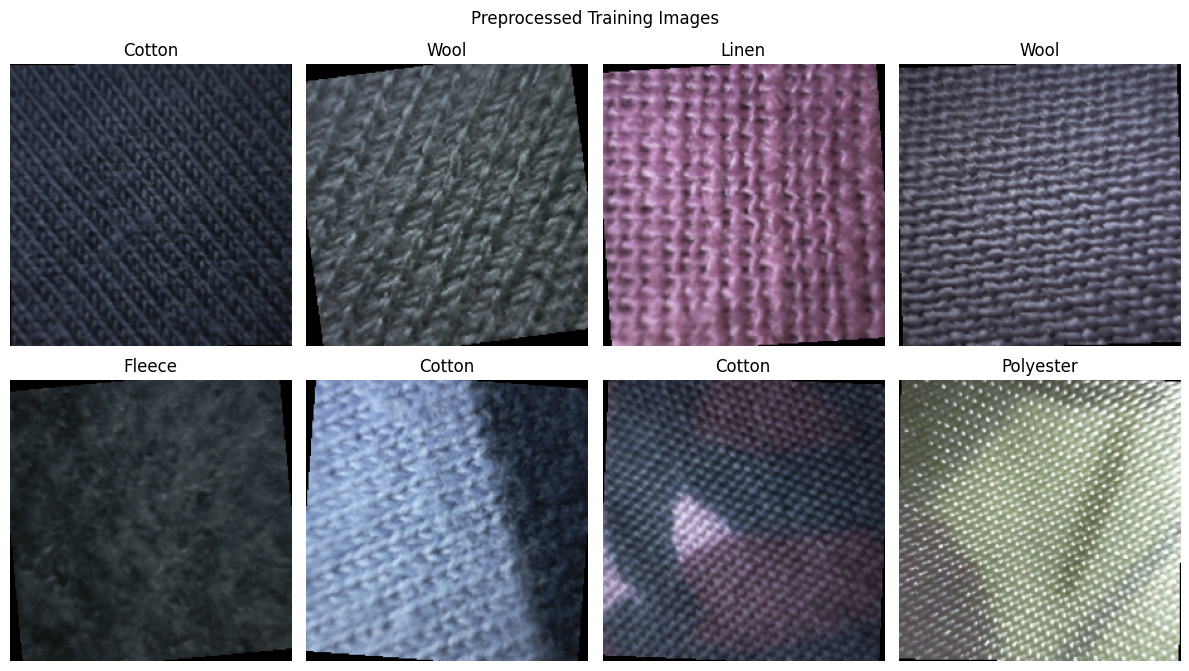

In [83]:
#display preprocessed images

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image_tensor):
    image_tensor = image_tensor.cpu()
    image_tensor = (
        image_tensor * IMAGENET_STD
        + IMAGENET_MEAN
    )

    return image_tensor.clamp(0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7)
)

for index, ax in enumerate(axes.flatten()):
    image = denormalize_image(images[index])

    image = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    label = labels[index].item()

    ax.imshow(image)
    ax.set_title(idx_to_class[label])
    ax.axis("off")

plt.suptitle("Preprocessed Training Images")
plt.tight_layout()
plt.show()

##Step 3: Feature Extraction using ResNet50

In [84]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

feature_extractor = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet50 feature extractor ready.")

ResNet50 feature extractor ready.


In [85]:
from tqdm.auto import tqdm
import numpy as np
import torch


def extract_features(model, data_loader, device, description="Extracting features"):
    model.eval()

    all_features = []
    all_labels = []

    progress_bar = tqdm(
        data_loader,
        desc=description,
        total=len(data_loader),
        unit="batch"
    )

    with torch.inference_mode():
        for images, labels in progress_bar:
            images = images.to(
                device,
                non_blocking=True
            )

            features = model(images)
            features = torch.flatten(features, start_dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

            progress_bar.set_postfix(
                batch_size=images.size(0),
                features=features.shape[1]
            )

    X = torch.cat(all_features, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()

    return X, y

In [86]:
X_train, y_train = extract_features(
    feature_extractor,
    train_loader,
    device,
    description="Training features"
)

print("Training features:", X_train.shape)
print("Training labels:", y_train.shape)

X_validation, y_validation = extract_features(
    feature_extractor,
    validation_loader,
    device,
    description="Validation features"
)

print("Validation features:", X_validation.shape)
print("Validation labels:", y_validation.shape)

X_test, y_test = extract_features(
    feature_extractor,
    test_loader,
    device,
    description="Testing features"
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features:   0%|          | 0/120 [00:00<?, ?batch/s]

Training features: (3824, 2048)
Training labels: (3824,)


Validation features:   0%|          | 0/26 [00:00<?, ?batch/s]

Validation features: (820, 2048)
Validation labels: (820,)


Testing features:   0%|          | 0/26 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781ffbd0b420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x781ffbd0b420>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^^
^ ^ ^ ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
       ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^  ^ ^ ^ ^ ^ ^ ^ ^
   File "/usr

Training features: (3824, 2048)
Testing features: (820, 2048)


In [87]:
# Preserve untouched master feature arrays
X_train_all = X_train.copy()
y_train_all = y_train.copy()

X_validation_all = X_validation.copy()
y_validation_all = y_validation.copy()

X_test_all = X_test.copy()
y_test_all = y_test.copy()

# Preserve the original class mappings
original_all_classes = all_classes_to_consider.copy()
original_class_to_idx = class_to_idx.copy()
original_idx_to_class = idx_to_class.copy()

print("Original feature arrays preserved.")

Original feature arrays preserved.


##Step 4: Selecting Classes + Baseline models

###Test: Top 7 unbalanced

In [202]:
import numpy as np

print(
    "Fleece old label:",
    original_class_to_idx.get("Fleece")
)

fleece_old_label = original_class_to_idx.get("Fleece")

if fleece_old_label is not None:
    print(
        "Training Fleece images:",
        np.sum(y_train_all == fleece_old_label)
    )

    print(
        "Validation Fleece images:",
        np.sum(y_validation_all == fleece_old_label)
    )

    print(
        "Testing Fleece images:",
        np.sum(y_test_all == fleece_old_label)
    )

Fleece old label: 7
Training Fleece images: 92
Validation Fleece images: 20
Testing Fleece images: 20


In [203]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [204]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [12, 11, 10, 9, 6, 8]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4, 'Silk': 5, 'Fleece': 6}

Training features: (3376, 2048)
Validation features: (724, 2048)
Testing features: (724, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160
Silk            | 140
Fleece          | 92


In [205]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [206]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.7762,0.7232,0.7565,0.7379
2,Random Forest,0.6865,0.8475,0.5239,0.5932
0,KNN Baseline,0.7030,0.7422,0.5287,0.5841


In [207]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']


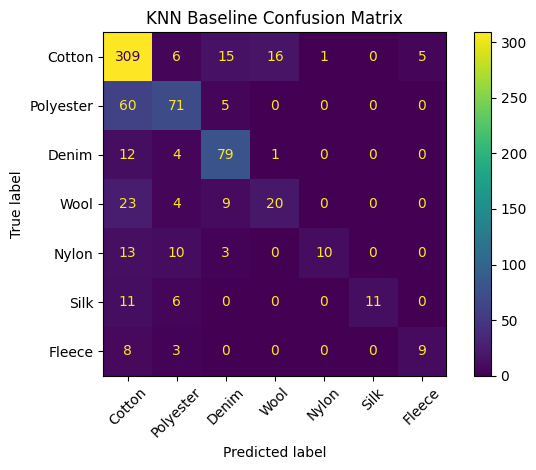

In [208]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

###Test: Same but only top 5 classes


In [209]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [210]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Silk",
    "Fleece",
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Silk', 'Fleece', 'Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [5, 7, 12, 11, 10, 9, 6, 8]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4}

Training features: (3144, 2048)
Validation features: (676, 2048)
Testing features: (672, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160


In [211]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [212]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.7973,0.7475,0.7843,0.7644
0,KNN Baseline,0.7308,0.7320,0.5748,0.6021
2,Random Forest,0.7189,0.8091,0.5260,0.5797


In [213]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth" and class_name != "Silk" and class_name != "Fleece"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']


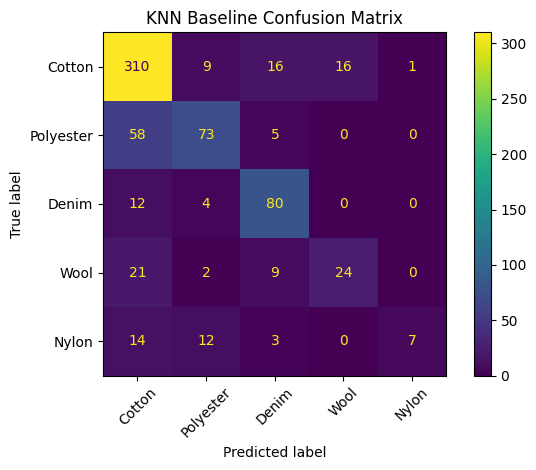

In [214]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

###Test: Undersampling top 7

In [215]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [216]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [12, 11, 10, 9, 6, 8]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4, 'Silk': 5, 'Fleece': 6}

Training features: (3376, 2048)
Validation features: (724, 2048)
Testing features: (724, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160
Silk            | 140
Fleece          | 92


In [217]:
# KEEP ONLY CURRENTLY SELECTED CLASSES

selected_classes = list(class_to_idx.keys())

filtered_train_samples = (
    train_samples[
        train_samples["class_name"].isin(selected_classes)
    ]
    .reset_index(drop=True)
    .copy()
)

print("Classes kept:")
print(
    filtered_train_samples["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Classes kept:
class_name
Cotton       412
Polyester    158
Denim        113
Wool          63
Nylon         40
Silk          35
Fleece        23
Name: count, dtype: int64


In [218]:
# LIMIT LARGE TRAINING CLASSES BY PHYSICAL SAMPLE

MAX_TRAIN_SAMPLES = 200

classes_to_cap = [
    "Cotton",
    "Polyester"
]

limited_train_groups = []

for class_name, class_group in filtered_train_samples.groupby(
    "class_name"
):
    # Cap only Cotton and Polyester
    if (
        class_name in classes_to_cap
        and len(class_group) > MAX_TRAIN_SAMPLES
    ):
        class_group = class_group.sample(
            n=MAX_TRAIN_SAMPLES,
            random_state=SEED
        )

    limited_train_groups.append(class_group)

limited_train_samples = (
    pd.concat(
        limited_train_groups,
        ignore_index=True
    )
    .reset_index(drop=True)
)

print("Training physical samples after limiting:")

print(
    limited_train_samples["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Training physical samples after limiting:
class_name
Cotton       200
Polyester    158
Denim        113
Wool          63
Nylon         40
Silk          35
Fleece        23
Name: count, dtype: int64


In [219]:
limited_train_images_df = select_images_from_sample_split(
    full_metadata_df,
    limited_train_samples
)

print("\nTraining images after undersampling:")

print(
    limited_train_images_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)


Training images after undersampling:
class_name
Cotton       800
Polyester    632
Denim        452
Wool         252
Nylon        160
Silk         140
Fleece        92
Name: count, dtype: int64


In [220]:
# RECREATE AND VALIDATE LABELS

limited_train_images_df = (
    limited_train_images_df
    .reset_index(drop=True)
    .copy()
)

# Remove label columns potentially created by a merge
label_columns = [
    column
    for column in limited_train_images_df.columns
    if column == "label" or column.startswith("label_")
]

limited_train_images_df = limited_train_images_df.drop(
    columns=label_columns,
    errors="ignore"
)

# Use the SAME mapping used for the original feature extraction
limited_train_images_df["label"] = (
    limited_train_images_df["class_name"]
    .map(class_to_idx)
)

# Show any classes that could not be mapped
missing_labels = limited_train_images_df[
    limited_train_images_df["label"].isna()
]

if not missing_labels.empty:
    print("Classes with missing labels:")
    print(
        missing_labels["class_name"]
        .value_counts()
    )

    raise ValueError(
        "Some class names are missing from class_to_idx."
    )

# Convert only after confirming there are no NaN values
limited_train_images_df["label"] = (
    limited_train_images_df["label"]
    .astype(int)
)

print("Missing labels:", limited_train_images_df["label"].isna().sum())

print("\nTraining images after undersampling:")
print(
    limited_train_images_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Missing labels: 0

Training images after undersampling:
class_name
Cotton       800
Polyester    632
Denim        452
Wool         252
Nylon        160
Silk         140
Fleece        92
Name: count, dtype: int64


In [221]:
limited_train_dataset = FabricDataset(
    limited_train_images_df,
    transform=train_transform
)

limited_train_loader = DataLoader(
    limited_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [222]:
# EXTRACT FEATURES FOR UNDERSAMPLED TRAINING DATA

X_train_undersampled, y_train_undersampled = extract_features(
    feature_extractor,
    limited_train_loader,
    device,
    description="Undersampled training features"
)

print("Undersampled training features:", X_train_undersampled.shape)

Undersampled training features:   0%|          | 0/79 [00:00<?, ?batch/s]

Undersampled training features: (2528, 2048)


In [223]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train_undersampled, y_train_undersampled)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [224]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.7030,0.6261,0.7190,0.6611
2,Random Forest,0.7320,0.7970,0.6164,0.6463
0,KNN Baseline,0.6257,0.6133,0.4868,0.5144


In [225]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']


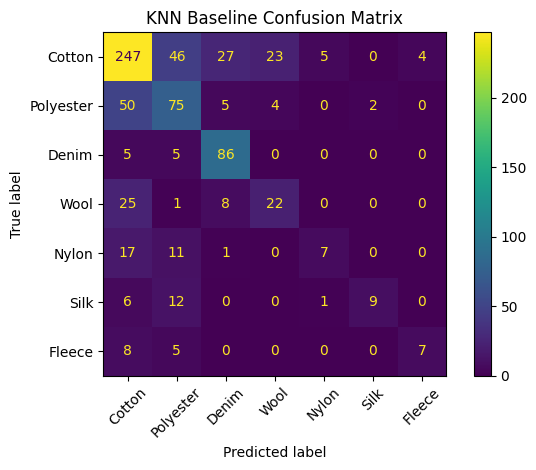

In [226]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

In [227]:
#print total number of samples in validation set
print("Total number of samples in validation set:", len(y_validation))

Total number of samples in validation set: 724


In [228]:
print("Number of predictions:", len(knn_predictions))
print("Number of validation labels:", len(y_validation))
print("Number of validation feature rows:", X_validation.shape[0])

assert len(knn_predictions) == len(y_validation)
assert X_validation.shape[0] == len(y_validation)

Number of predictions: 724
Number of validation labels: 724
Number of validation feature rows: 724


###Test: Same Undersampling but only top 5 classes

In [229]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Silk",
    "Fleece",
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Silk', 'Fleece', 'Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [5, 6]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4}

Training features: (3144, 2048)
Validation features: (676, 2048)
Testing features: (672, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160


In [230]:
# KEEP ONLY CURRENTLY SELECTED CLASSES

selected_classes = list(class_to_idx.keys())

filtered_train_samples = (
    train_samples[
        train_samples["class_name"].isin(selected_classes)
    ]
    .reset_index(drop=True)
    .copy()
)

print("Classes kept:")
print(
    filtered_train_samples["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Classes kept:
class_name
Cotton       412
Polyester    158
Denim        113
Wool          63
Nylon         40
Name: count, dtype: int64


In [231]:
# LIMIT LARGE TRAINING CLASSES BY PHYSICAL SAMPLE

MAX_TRAIN_SAMPLES = 200

classes_to_cap = [
    "Cotton",
    "Polyester"
]

limited_train_groups = []

for class_name, class_group in filtered_train_samples.groupby(
    "class_name"
):
    # Cap only Cotton and Polyester
    if (
        class_name in classes_to_cap
        and len(class_group) > MAX_TRAIN_SAMPLES
    ):
        class_group = class_group.sample(
            n=MAX_TRAIN_SAMPLES,
            random_state=SEED
        )

    limited_train_groups.append(class_group)

limited_train_samples = (
    pd.concat(
        limited_train_groups,
        ignore_index=True
    )
    .reset_index(drop=True)
)

print("Training physical samples after limiting:")

print(
    limited_train_samples["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Training physical samples after limiting:
class_name
Cotton       200
Polyester    158
Denim        113
Wool          63
Nylon         40
Name: count, dtype: int64


In [232]:
limited_train_images_df = select_images_from_sample_split(
    full_metadata_df,
    limited_train_samples
)

print("\nTraining images after undersampling:")

print(
    limited_train_images_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)


Training images after undersampling:
class_name
Cotton       800
Polyester    632
Denim        452
Wool         252
Nylon        160
Name: count, dtype: int64


In [233]:
# RECREATE AND VALIDATE LABELS

limited_train_images_df = (
    limited_train_images_df
    .reset_index(drop=True)
    .copy()
)

# Remove label columns potentially created by a merge
label_columns = [
    column
    for column in limited_train_images_df.columns
    if column == "label" or column.startswith("label_")
]

limited_train_images_df = limited_train_images_df.drop(
    columns=label_columns,
    errors="ignore"
)

# Use the SAME mapping used for the original feature extraction
limited_train_images_df["label"] = (
    limited_train_images_df["class_name"]
    .map(class_to_idx)
)

# Show any classes that could not be mapped
missing_labels = limited_train_images_df[
    limited_train_images_df["label"].isna()
]

if not missing_labels.empty:
    print("Classes with missing labels:")
    print(
        missing_labels["class_name"]
        .value_counts()
    )

    raise ValueError(
        "Some class names are missing from class_to_idx."
    )

# Convert only after confirming there are no NaN values
limited_train_images_df["label"] = (
    limited_train_images_df["label"]
    .astype(int)
)

print("Missing labels:", limited_train_images_df["label"].isna().sum())

print("\nTraining images after undersampling:")
print(
    limited_train_images_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

Missing labels: 0

Training images after undersampling:
class_name
Cotton       800
Polyester    632
Denim        452
Wool         252
Nylon        160
Name: count, dtype: int64


In [234]:
limited_train_dataset = FabricDataset(
    limited_train_images_df,
    transform=train_transform
)

limited_train_loader = DataLoader(
    limited_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [235]:
# EXTRACT FEATURES FOR UNDERSAMPLED TRAINING DATA

X_train_undersampled, y_train_undersampled = extract_features(
    feature_extractor,
    limited_train_loader,
    device,
    description="Undersampled training features"
)

print("Undersampled training features:", X_train_undersampled.shape)

Undersampled training features:   0%|          | 0/72 [00:00<?, ?batch/s]

Undersampled training features: (2296, 2048)


In [236]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train_undersampled, y_train_undersampled)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [237]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,Random Forest,0.7737,0.8202,0.6583,0.6850
1,Logistic Regression,0.7071,0.6391,0.7311,0.6724
0,KNN Baseline,0.6627,0.5957,0.5725,0.5689


In [238]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth" and class_name != "Silk" and class_name != "Fleece"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']


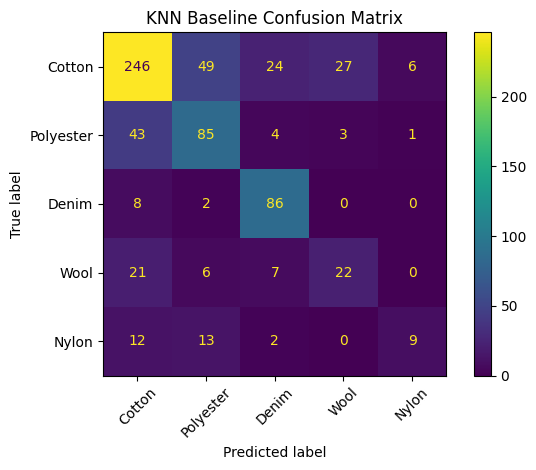

In [239]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

In [240]:
#print total number of samples in validation set
print("Total number of samples in validation set:", len(y_validation))

Total number of samples in validation set: 676


In [241]:
print("Number of predictions:", len(knn_predictions))
print("Number of validation labels:", len(y_validation))
print("Number of validation feature rows:", X_validation.shape[0])

assert len(knn_predictions) == len(y_validation)
assert X_validation.shape[0] == len(y_validation)

Number of predictions: 676
Number of validation labels: 676
Number of validation feature rows: 676


###Test: Undersampling Without Cotton

In [242]:
import numpy as np

# Cotton's existing numerical label
cotton_label = class_to_idx["Cotton"]

# Preserve class order while excluding Cotton
remaining_classes = [
    class_name
    for class_name, old_label in sorted(
        class_to_idx.items(),
        key=lambda item: item[1]
    )
    if class_name != "Cotton"
]

# Create a fresh contiguous label mapping
class_to_idx_no_cotton = {
    class_name: new_label
    for new_label, class_name in enumerate(remaining_classes)
}

idx_to_class_no_cotton = {
    label: class_name
    for class_name, label in class_to_idx_no_cotton.items()
}

old_to_new_label = {
    class_to_idx[class_name]: class_to_idx_no_cotton[class_name]
    for class_name in remaining_classes
}


def remove_cotton_and_remap(X, y):
    mask = y != cotton_label

    X_filtered = X[mask]
    old_y_filtered = y[mask].astype(int)

    y_filtered = np.array(
        [
            old_to_new_label[int(label)]
            for label in old_y_filtered
        ],
        dtype=np.int64
    )

    return X_filtered, y_filtered

In [243]:
X_train_no_cotton, y_train_no_cotton = (
    remove_cotton_and_remap(
        X_train_undersampled,
        y_train_undersampled
    )
)

X_validation_no_cotton, y_validation_no_cotton = (
    remove_cotton_and_remap(
        X_validation,
        y_validation
    )
)

print("Training without Cotton:", X_train_no_cotton.shape)

print("Original validation:", X_validation.shape)
print("Validation without Cotton:", X_validation_no_cotton.shape)

print("Classes:", remaining_classes)

Training without Cotton: (1496, 2048)
Original validation: (676, 2048)
Validation without Cotton: (324, 2048)
Classes: ['Polyester', 'Denim', 'Wool', 'Nylon']


In [244]:
for name, model in models.items():
    model.fit(
        X_train_no_cotton,
        y_train_no_cotton
    )

    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [245]:
results = []

for name, model in models.items():
    predictions = model.predict(
        X_validation_no_cotton
    )

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_validation_no_cotton,
            predictions
        ),

        "Macro Precision": precision_score(
            y_validation_no_cotton,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_validation_no_cotton,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_validation_no_cotton,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_no_cotton_df = pd.DataFrame(results)

display(
    results_no_cotton_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.8272,0.7972,0.8221,0.8057
2,Random Forest,0.8272,0.8778,0.7145,0.7523
0,KNN Baseline,0.7685,0.7605,0.6711,0.6953


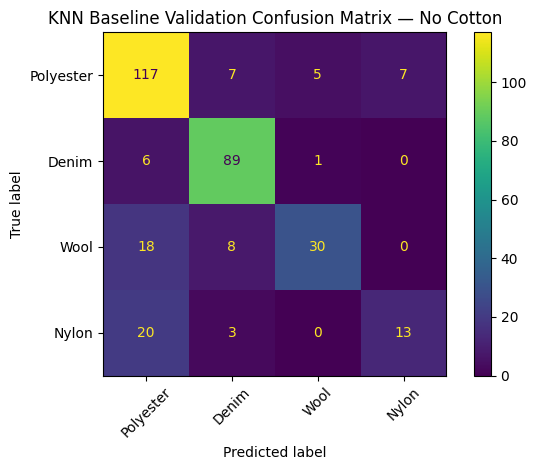

In [246]:
model_name = "KNN Baseline"

predictions = models[
    model_name
].predict(X_validation_no_cotton)

ConfusionMatrixDisplay.from_predictions(
    y_validation_no_cotton,
    predictions,
    labels=range(len(remaining_classes)),
    display_labels=remaining_classes,
    xticks_rotation=45
)

plt.title(
    f"{model_name} Validation Confusion Matrix — No Cotton"
)

plt.tight_layout()
plt.show()

###Test: Without Cotton on unbalanced dataset

In [247]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [248]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
    "Cotton",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth', 'Cotton']
Removing old labels: [12, 11, 10, 9, 6, 8, 0]

Remaining classes:
['Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']

Updated class mapping:
{'Polyester': 0, 'Denim': 1, 'Wool': 2, 'Nylon': 3, 'Silk': 4, 'Fleece': 5}

Training features: (1728, 2048)
Validation features: (372, 2048)
Testing features: (372, 2048)

Training images per remaining class:
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160
Silk            | 140
Fleece          | 92


In [249]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [250]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.8199,0.7768,0.7953,0.7837
2,Random Forest,0.7688,0.8949,0.6349,0.6898
0,KNN Baseline,0.7366,0.8391,0.6037,0.6653


In [251]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth" and class_name != "Cotton"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Polyester', 'Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']


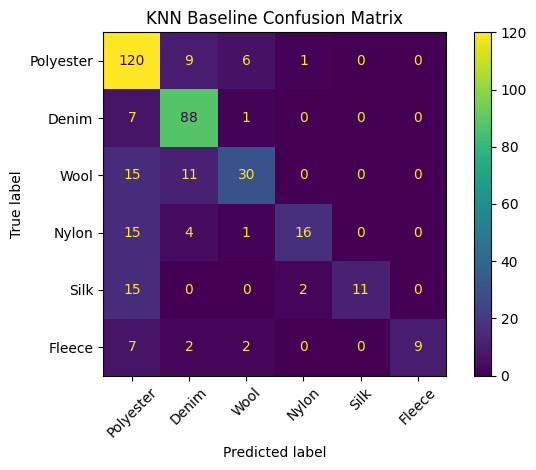

In [252]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

###Test: Without Cotton and Polyester, no undersampling

In [253]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
    "Cotton",
    "Polyester",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth', 'Cotton', 'Polyester']
Removing old labels: [0]

Remaining classes:
['Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']

Updated class mapping:
{'Denim': 0, 'Wool': 1, 'Nylon': 2, 'Silk': 3, 'Fleece': 4}

Training features: (1096, 2048)
Validation features: (236, 2048)
Testing features: (236, 2048)

Training images per remaining class:
Denim           | 452
Wool            | 252
Nylon           | 160
Silk            | 140
Fleece          | 92


In [254]:
#need extract feature function to have short runtime to run this cell
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN Baseline": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained.")

KNN Baseline trained.
Logistic Regression trained.
Random Forest trained.


In [255]:
# preliminary results

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():
    predictions = model.predict(X_validation)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Precision": precision_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df
    .sort_values("Macro F1", ascending=False)
    .round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.9322,0.9133,0.9200,0.9158
2,Random Forest,0.8686,0.9003,0.8426,0.8629
0,KNN Baseline,0.7797,0.8293,0.6808,0.7272


In [256]:
all_classes_selected = [
    class_name
    for class_name in all_classes_to_consider
    if class_name != "Linen" and class_name != "Satin" and class_name != "Corduroy" and class_name != "Crepe" and class_name != "Viscose" and class_name != "Terrycloth" and class_name != "Cotton" and class_name != "Polyester"
]

print("Updated classes:")
print(all_classes_selected)

Updated classes:
['Denim', 'Wool', 'Nylon', 'Silk', 'Fleece']


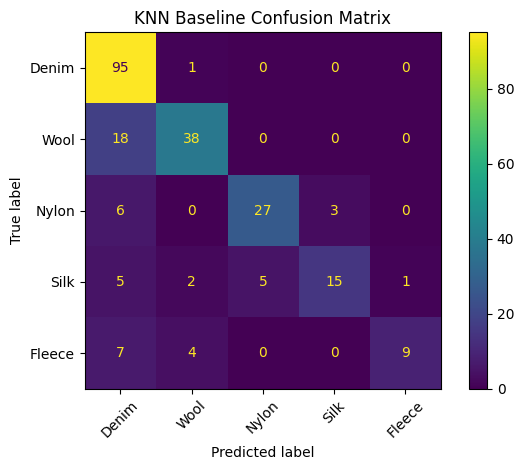

In [257]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

knn_predictions = models[
    "KNN Baseline"
].predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    knn_predictions,
    display_labels=all_classes_selected,
    xticks_rotation=45
)

plt.title("KNN Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

##Step 5: MLP Model

In [258]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [259]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Silk",
    "Fleece",
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Silk', 'Fleece', 'Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [5, 7, 12, 11, 10, 9, 6, 8]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4}

Training features: (3144, 2048)
Validation features: (676, 2048)
Testing features: (672, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160


In [260]:
import numpy as np
from collections import Counter

mlp_classes = [
    "Cotton",
    "Polyester",
    "Denim",
    "Wool",
    "Nylon",
]

# Original labels from the master mapping
mlp_old_labels = [
    original_class_to_idx[class_name]
    for class_name in mlp_classes
]

# New contiguous labels: 0, 1, 2, ...
mlp_class_to_idx = {
    class_name: new_label
    for new_label, class_name in enumerate(mlp_classes)
}

mlp_idx_to_class = {
    label: class_name
    for class_name, label in mlp_class_to_idx.items()
}

old_to_new_mlp_label = {
    original_class_to_idx[class_name]:
    mlp_class_to_idx[class_name]
    for class_name in mlp_classes
}


def create_mlp_split(X, y):
    # Keep only the desired classes
    mask = np.isin(y, mlp_old_labels)

    X_selected = X[mask].copy()
    y_old = y[mask].astype(int)

    # Remap original labels to 0 through 6
    y_selected = np.array(
        [
            old_to_new_mlp_label[int(label)]
            for label in y_old
        ],
        dtype=np.int64
    )

    return X_selected, y_selected

In [261]:
X_train_mlp, y_train_mlp = create_mlp_split(
    X_train_all,
    y_train_all
)

X_validation_mlp, y_validation_mlp = create_mlp_split(
    X_validation_all,
    y_validation_all
)

X_test_mlp, y_test_mlp = create_mlp_split(
    X_test_all,
    y_test_all
)

In [262]:
print("MLP class mapping:")
print(mlp_class_to_idx)

print("\nTraining classes and image counts:")

for label, count in sorted(Counter(y_train_mlp).items()):
    print(
        f"Label {label}: "
        f"{mlp_idx_to_class[int(label)]:12s} | "
        f"{count} images"
    )

print("\nDataset shapes:")
print("Training:", X_train_mlp.shape, y_train_mlp.shape)
print("Validation:", X_validation_mlp.shape, y_validation_mlp.shape)
print("Testing:", X_test_mlp.shape, y_test_mlp.shape)

assert "Cotton" in mlp_class_to_idx
assert "Polyester" in mlp_class_to_idx
assert set(np.unique(y_train_mlp)) == set(range(len(mlp_classes)))

MLP class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4}

Training classes and image counts:
Label 0: Cotton       | 1648 images
Label 1: Polyester    | 632 images
Label 2: Denim        | 452 images
Label 3: Wool         | 252 images
Label 4: Nylon        | 160 images

Dataset shapes:
Training: (3144, 2048) (3144,)
Validation: (676, 2048) (676,)
Testing: (672, 2048) (672,)


###Hyper Parameter Tuning

In [272]:
# MLP HYPERPARAMETER TUNING

import time
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import ParameterGrid


#hyper params to explore (using grid)
param_grid = {
    # 3 hidden-layer choices
    "hidden_layer_sizes": [
        (64,),
        (128, 64),
        (256, 128)
    ],
    #2 learning rates
    "learning_rate_init": [
        0.0005,
        0.001
    ],

    #for regularization. (L2)
    "alpha": [
        0.0001,
        0.001
    ]
}


#tuning results
tuning_results = []

overall_start = time.perf_counter()

for run_number, params in enumerate(
    ParameterGrid(param_grid),
    start=1
):

    print(f"Run {run_number}: layers={params['hidden_layer_sizes']}, lr={params['learning_rate_init']}, alpha={params['alpha']}")

    mlp = make_pipeline(
        StandardScaler(),

        MLPClassifier(
            hidden_layer_sizes=params["hidden_layer_sizes"],
            activation="relu",
            solver="adam",
            learning_rate_init=params["learning_rate_init"],
            batch_size=64,
            alpha=params["alpha"],
            max_iter=500,

            # Regularization / overfitting control
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,

            random_state=SEED
        )
    )

    run_start = time.perf_counter()

    # Fit ONLY on training data
    mlp.fit(
        X_train_mlp,
        y_train_mlp
    )

    run_time = time.perf_counter() - run_start

    # Evaluate on validation data
    validation_predictions = mlp.predict(
        X_validation_mlp
    )

    validation_accuracy = accuracy_score(
        y_validation_mlp,
        validation_predictions
    )

    validation_macro_f1 = f1_score(
        y_validation_mlp,
        validation_predictions,
        average="macro"
    )

    # Get fitted sklearn MLP
    fitted_mlp = mlp.named_steps[
        "mlpclassifier"
    ]

    tuning_results.append({
        "Hidden Layers": params["hidden_layer_sizes"],
        "Learning Rate": params["learning_rate_init"],
        "Alpha": params["alpha"],
        "Epochs": fitted_mlp.n_iter_,
        "Validation Accuracy": validation_accuracy,
        "Validation Macro F1": validation_macro_f1,
        "Runtime (sec)": run_time})

Run 1: layers=(64,), lr=0.0005, alpha=0.0001
Run 2: layers=(64,), lr=0.001, alpha=0.0001
Run 3: layers=(128, 64), lr=0.0005, alpha=0.0001
Run 4: layers=(128, 64), lr=0.001, alpha=0.0001
Run 5: layers=(256, 128), lr=0.0005, alpha=0.0001
Run 6: layers=(256, 128), lr=0.001, alpha=0.0001
Run 7: layers=(64,), lr=0.0005, alpha=0.001
Run 8: layers=(64,), lr=0.001, alpha=0.001
Run 9: layers=(128, 64), lr=0.0005, alpha=0.001
Run 10: layers=(128, 64), lr=0.001, alpha=0.001
Run 11: layers=(256, 128), lr=0.0005, alpha=0.001
Run 12: layers=(256, 128), lr=0.001, alpha=0.001


In [273]:
#results:

total_tuning_time = (
    time.perf_counter() - overall_start
)

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        by=[
            "Validation Macro F1",
            "Validation Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuning_results_df.round(4)
)


,Hidden Layers,Learning Rate,Alpha,Epochs,Validation Accuracy,Validation Macro F1,Runtime (sec)
0,"(128, 64)",0.0010,0.0001,26,0.8269,0.7829,6.2560
1,"(128, 64)",0.0005,0.0001,25,0.8254,0.7748,10.2344
2,"(256, 128)",0.0005,0.0001,27,0.8180,0.7735,21.2480
3,"(128, 64)",0.0010,0.0010,22,0.8269,0.7733,9.6778
4,"(256, 128)",0.0010,0.0010,40,0.8092,0.7697,28.0778
5,"(256, 128)",0.0005,0.0010,27,0.8151,0.7685,17.5214
6,"(256, 128)",0.0010,0.0001,50,0.8077,0.7654,33.6858
7,"(128, 64)",0.0005,0.0010,28,0.8180,0.7619,6.7724
8,"(64,)",0.0005,0.0001,46,0.8092,0.7522,7.0153
9,"(64,)",0.0005,0.0010,46,0.8092,0.7522,5.8140


In [274]:
#figure out the best configuration

best_row = tuning_results_df.iloc[0]

best_mlp_params = {
    "hidden_layer_sizes":
        best_row["Hidden Layers"],

    "learning_rate_init":
        float(best_row["Learning Rate"]),

    "alpha":
        float(best_row["Alpha"])
}

print("\nBEST MLP HYPERPARAMETERS")
print("-" * 40)

print("Hidden layers:", best_mlp_params["hidden_layer_sizes"])

print("Learning rate:", best_mlp_params["learning_rate_init"])

print("Alpha:", best_mlp_params["alpha"])

print("Best Validation Macro F1:", round(best_row["Validation Macro F1"], 4))

print("Best Validation Accuracy:", round(best_row["Validation Accuracy"], 4))

print(f"\nTotal tuning runtime: " f"{total_tuning_time / 60:.2f} minutes")


BEST MLP HYPERPARAMETERS
----------------------------------------
Hidden layers: (128, 64)
Learning rate: 0.001
Alpha: 0.0001
Best Validation Macro F1: 0.7829
Best Validation Accuracy: 0.8269

Total tuning runtime: 4.21 minutes


In [275]:
# Rerun best model

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

mlp_model = make_pipeline(
    StandardScaler(),

    MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        batch_size=64,
        alpha=0.0001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=42
    )
)

mlp_model.fit(X_train_mlp, y_train_mlp)

train_accuracy = mlp_model.score(
    X_train_mlp,
    y_train_mlp
)

validation_accuracy = mlp_model.score(
    X_validation_mlp,
    y_validation_mlp
)

y_pred_mlp = mlp_model.predict(
    X_validation_mlp
)

cr_mlp = classification_report(
    y_validation_mlp,
    y_pred_mlp,
    target_names=mlp_classes
)

print("Classification Report for MLP:")
print(cr_mlp)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

Classification Report for MLP:
              precision    recall  f1-score   support

      Cotton       0.85      0.88      0.87       352
   Polyester       0.72      0.74      0.73       136
       Denim       0.94      0.95      0.94        96
        Wool       0.75      0.59      0.66        56
       Nylon       0.74      0.69      0.71        36

    accuracy                           0.83       676
   macro avg       0.80      0.77      0.78       676
weighted avg       0.82      0.83      0.83       676

Training Accuracy: 0.9879
Validation Accuracy: 0.8269


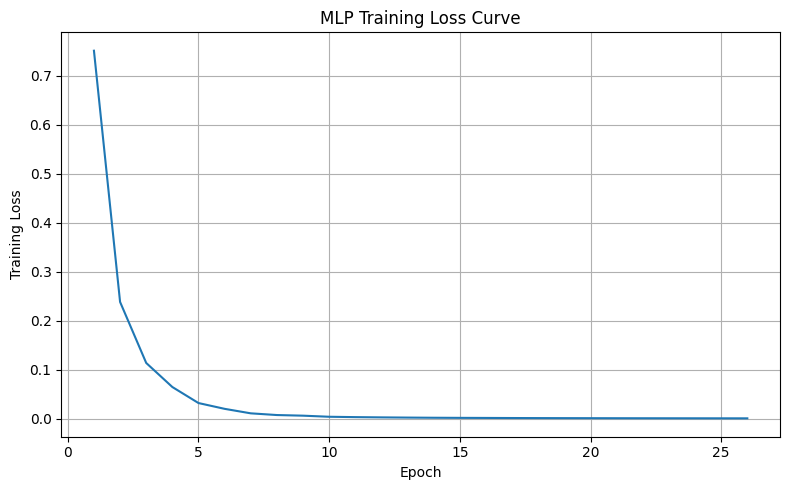

Actual epochs completed: 26


In [276]:
#training loss curve
import matplotlib.pyplot as plt

fitted_mlp = mlp_model.named_steps["mlpclassifier"]

epochs = range(
    1,
    len(fitted_mlp.loss_curve_) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    fitted_mlp.loss_curve_
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Actual epochs completed:", fitted_mlp.n_iter_)

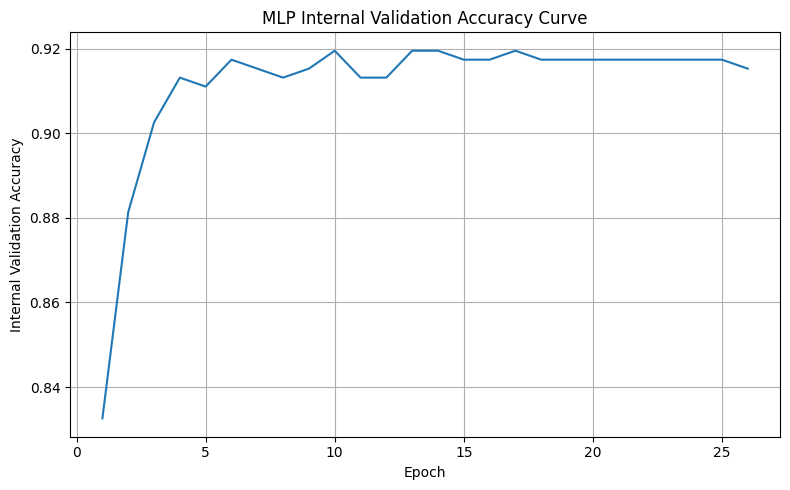

In [277]:
#internal validation accruayc score
if fitted_mlp.validation_scores_ is not None:

    validation_epochs = range(
        1,
        len(fitted_mlp.validation_scores_) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        validation_epochs,
        fitted_mlp.validation_scores_
    )

    plt.xlabel("Epoch")
    plt.ylabel("Internal Validation Accuracy")
    plt.title("MLP Internal Validation Accuracy Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##Step 6: LSTM Model

In [278]:
import pandas as pd

lstm_classes = [
    "Cotton",
    "Polyester",
    "Denim",
    "Wool",
    "Nylon",
]

lstm_class_to_idx = {
    class_name: index
    for index, class_name in enumerate(lstm_classes)
}

lstm_idx_to_class = {
    index: class_name
    for class_name, index in lstm_class_to_idx.items()
}


def prepare_lstm_dataframe(image_df):
    selected_df = (
        image_df[
            image_df["class_name"].isin(lstm_classes)
        ]
        .copy()
        .reset_index(drop=True)
    )

    selected_df["label"] = (
        selected_df["class_name"]
        .map(lstm_class_to_idx)
        .astype(int)
    )

    return selected_df

In [279]:
lstm_train_images_df = prepare_lstm_dataframe(
    train_images_df
)

lstm_validation_images_df = prepare_lstm_dataframe(
    validation_images_df
)

lstm_test_images_df = prepare_lstm_dataframe(
    test_images_df
)

print("Training:")
print(lstm_train_images_df["class_name"].value_counts())

print("\nValidation:")
print(lstm_validation_images_df["class_name"].value_counts())

print("\nTesting:")
print(lstm_test_images_df["class_name"].value_counts())

Training:
class_name
Cotton       1648
Polyester     632
Denim         452
Wool          252
Nylon         160
Name: count, dtype: int64

Validation:
class_name
Cotton       352
Polyester    136
Denim         96
Wool          56
Nylon         36
Name: count, dtype: int64

Testing:
class_name
Cotton       352
Polyester    136
Denim        100
Wool          52
Nylon         32
Name: count, dtype: int64


In [280]:
assert set(
    lstm_train_images_df["class_name"].unique()
) == set(lstm_classes)

In [281]:
#create patch extraction
from torch.utils.data import DataLoader

PATCH_EXTRACTION_BATCH_SIZE = 32

lstm_train_image_dataset = FabricDataset(
    lstm_train_images_df,
    transform=train_transform
)

lstm_validation_image_dataset = FabricDataset(
    lstm_validation_images_df,
    transform=evaluation_transform
)

lstm_test_image_dataset = FabricDataset(
    lstm_test_images_df,
    transform=evaluation_transform
)

lstm_train_image_loader = DataLoader(
    lstm_train_image_dataset,
    batch_size=PATCH_EXTRACTION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

lstm_validation_image_loader = DataLoader(
    lstm_validation_image_dataset,
    batch_size=PATCH_EXTRACTION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

lstm_test_image_loader = DataLoader(
    lstm_test_image_dataset,
    batch_size=PATCH_EXTRACTION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [282]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

weights = ResNet50_Weights.DEFAULT

resnet_patch_model = resnet50(
    weights=weights
)

# Remove average pooling and classification layer
resnet_patch_extractor = nn.Sequential(
    *list(resnet_patch_model.children())[:-2]
)

resnet_patch_extractor = (
    resnet_patch_extractor
    .to(device)
    .eval()
)

# Freeze ResNet50
for parameter in resnet_patch_extractor.parameters():
    parameter.requires_grad = False

In [283]:
from tqdm.auto import tqdm


def extract_patch_embeddings(
    model,
    data_loader,
    device,
    grid_size=(4, 4),
    description="Patch embeddings"
):
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in tqdm(
            data_loader,
            desc=description,
            unit="batch"
        ):
            images = images.to(
                device,
                non_blocking=True
            )

            # Shape: batch × 2048 × 7 × 7
            feature_maps = model(images)

            # Shape: batch × 2048 × 4 × 4
            feature_maps = F.adaptive_avg_pool2d(
                feature_maps,
                output_size=grid_size
            )

            # Shape: batch × 16 × 2048
            patch_embeddings = (
                feature_maps
                .flatten(start_dim=2)
                .transpose(1, 2)
            )

            # Store as float16 to reduce memory usage
            all_embeddings.append(
                patch_embeddings
                .cpu()
                .half()
            )

            all_labels.append(
                labels.cpu().long()
            )

    X_patches = torch.cat(
        all_embeddings,
        dim=0
    )

    y_patches = torch.cat(
        all_labels,
        dim=0
    )

    return X_patches, y_patches

In [284]:
#extract patches
X_train_patches, y_train_lstm = extract_patch_embeddings(
    resnet_patch_extractor,
    lstm_train_image_loader,
    device,
    description="Training patch embeddings"
)

X_validation_patches, y_validation_lstm = extract_patch_embeddings(
    resnet_patch_extractor,
    lstm_validation_image_loader,
    device,
    description="Validation patch embeddings"
)

X_test_patches, y_test_lstm = extract_patch_embeddings(
    resnet_patch_extractor,
    lstm_test_image_loader,
    device,
    description="Testing patch embeddings"
)

print("Training:", X_train_patches.shape)
print("Validation:", X_validation_patches.shape)
print("Testing:", X_test_patches.shape)

Training patch embeddings:   0%|          | 0/99 [00:00<?, ?batch/s]

Validation patch embeddings:   0%|          | 0/22 [00:00<?, ?batch/s]

Testing patch embeddings:   0%|          | 0/21 [00:00<?, ?batch/s]

Training: torch.Size([3144, 16, 2048])
Validation: torch.Size([676, 16, 2048])
Testing: torch.Size([672, 16, 2048])


In [285]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

LSTM_BATCH_SIZE = 32

lstm_train_dataset = TensorDataset(
    X_train_patches,
    y_train_lstm
)

lstm_validation_dataset = TensorDataset(
    X_validation_patches,
    y_validation_lstm
)

lstm_test_dataset = TensorDataset(
    X_test_patches,
    y_test_lstm
)

lstm_train_loader = DataLoader(
    lstm_train_dataset,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=True
)

lstm_validation_loader = DataLoader(
    lstm_validation_dataset,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False
)

lstm_test_loader = DataLoader(
    lstm_test_dataset,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False
)

In [286]:
class FabricPatchLSTM(nn.Module):
    def __init__(
        self,
        input_size=2048,
        projection_size=256,
        hidden_size=128,
        num_layers=2,
        num_classes=7,
        dropout=0.3
    ):
        super().__init__()

        # Reduce each patch from 2048 to 256 features
        self.patch_projection = nn.Sequential(
            nn.Linear(
                input_size,
                projection_size
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.lstm = nn.LSTM(
            input_size=projection_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(
                hidden_size,
                num_classes
            )
        )

    def forward(self, x):
        # x: batch × 16 × 2048
        x = self.patch_projection(x)

        # output: batch × 16 × hidden_size
        output, _ = self.lstm(x)

        # Hidden representation after final patch
        final_output = output[:, -1, :]

        return self.classifier(final_output)

In [287]:
torch.manual_seed(SEED)

lstm_model = FabricPatchLSTM(
    input_size=2048,
    projection_size=256,
    hidden_size=128,
    num_layers=2,
    num_classes=len(lstm_classes),
    dropout=0.3
).to(device)

print(lstm_model)

FabricPatchLSTM(
  (patch_projection): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [288]:
import torch.optim as optim

LSTM_LEARNING_RATE = 0.001
LSTM_MAX_EPOCHS = 30
LSTM_WEIGHT_DECAY = 0.0001
LSTM_PATIENCE = 5

# Multiclass cross-entropy loss
criterion = nn.CrossEntropyLoss()

# AdamW optimizer with L2-style weight decay
optimizer = optim.AdamW(
    lstm_model.parameters(),
    lr=LSTM_LEARNING_RATE,
    weight_decay=LSTM_WEIGHT_DECAY
)

In [289]:
import copy
import numpy as np

from sklearn.metrics import f1_score


def evaluate_lstm(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    total_correct = 0
    total_examples = 0

    all_predictions = []
    all_targets = []

    with torch.inference_mode():
        for features, labels in data_loader:
            features = features.to(
                device,
                dtype=torch.float32
            )

            labels = labels.to(device)

            logits = model(features)
            loss = criterion(logits, labels)

            predictions = logits.argmax(dim=1)

            running_loss += (
                loss.item() * labels.size(0)
            )

            total_correct += (
                predictions == labels
            ).sum().item()

            total_examples += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                labels.cpu().numpy()
            )

    average_loss = (
        running_loss / total_examples
    )

    accuracy = (
        total_correct / total_examples
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        average_loss,
        accuracy,
        macro_f1,
        np.array(all_targets),
        np.array(all_predictions)
    )

In [290]:
def train_lstm(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=30,
    patience=5
):
    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_accuracy": [],
        "validation_accuracy": [],
        "validation_macro_f1": []
    }

    best_validation_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        running_loss = 0.0
        total_correct = 0
        total_examples = 0

        for features, labels in train_loader:
            features = features.to(
                device,
                dtype=torch.float32
            )

            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(features)
            loss = criterion(logits, labels)

            loss.backward()

            # Recurrent-model regularization
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            predictions = logits.argmax(dim=1)

            running_loss += (
                loss.item() * labels.size(0)
            )

            total_correct += (
                predictions == labels
            ).sum().item()

            total_examples += labels.size(0)

        train_loss = (
            running_loss / total_examples
        )

        train_accuracy = (
            total_correct / total_examples
        )

        (
            validation_loss,
            validation_accuracy,
            validation_macro_f1,
            _,
            _
        ) = evaluate_lstm(
            model,
            validation_loader,
            criterion,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["validation_loss"].append(
            validation_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["validation_accuracy"].append(
            validation_accuracy
        )

        history["validation_macro_f1"].append(
            validation_macro_f1
        )

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Validation Accuracy: {validation_accuracy:.4f} | "
            f"Validation Macro F1: {validation_macro_f1:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(
                    f"Early stopping at epoch {epoch}."
                )
                break

    model.load_state_dict(
        best_model_state
    )

    history["epochs_completed"] = len(
        history["train_loss"]
    )

    return history

In [291]:
lstm_history = train_lstm(
    model=lstm_model,
    train_loader=lstm_train_loader,
    validation_loader=lstm_validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=LSTM_MAX_EPOCHS,
    patience=LSTM_PATIENCE
)

print(
    "Actual epochs completed:",
    lstm_history["epochs_completed"]
)

Epoch 01/30 | Train Loss: 0.8645 | Validation Loss: 0.5908 | Train Accuracy: 0.6724 | Validation Accuracy: 0.7781 | Validation Macro F1: 0.6640
Epoch 02/30 | Train Loss: 0.5104 | Validation Loss: 0.5363 | Train Accuracy: 0.8232 | Validation Accuracy: 0.7870 | Validation Macro F1: 0.7241
Epoch 03/30 | Train Loss: 0.3664 | Validation Loss: 0.5310 | Train Accuracy: 0.8709 | Validation Accuracy: 0.8254 | Validation Macro F1: 0.7578
Epoch 04/30 | Train Loss: 0.2960 | Validation Loss: 0.5929 | Train Accuracy: 0.8989 | Validation Accuracy: 0.8018 | Validation Macro F1: 0.7355
Epoch 05/30 | Train Loss: 0.2393 | Validation Loss: 0.5782 | Train Accuracy: 0.9240 | Validation Accuracy: 0.8195 | Validation Macro F1: 0.7781
Epoch 06/30 | Train Loss: 0.1934 | Validation Loss: 0.6417 | Train Accuracy: 0.9316 | Validation Accuracy: 0.7959 | Validation Macro F1: 0.7402
Epoch 07/30 | Train Loss: 0.1797 | Validation Loss: 0.7238 | Train Accuracy: 0.9370 | Validation Accuracy: 0.8033 | Validation Macro F1:

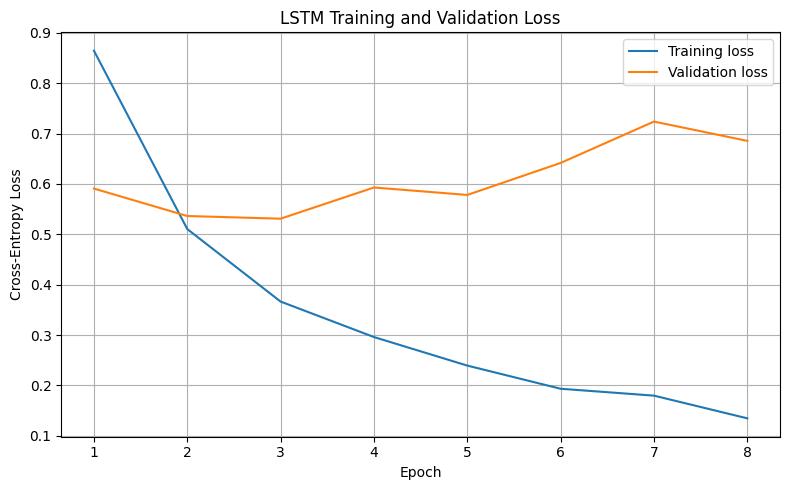

In [292]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    lstm_history["epochs_completed"] + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    lstm_history["train_loss"],
    label="Training loss"
)

plt.plot(
    epochs,
    lstm_history["validation_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

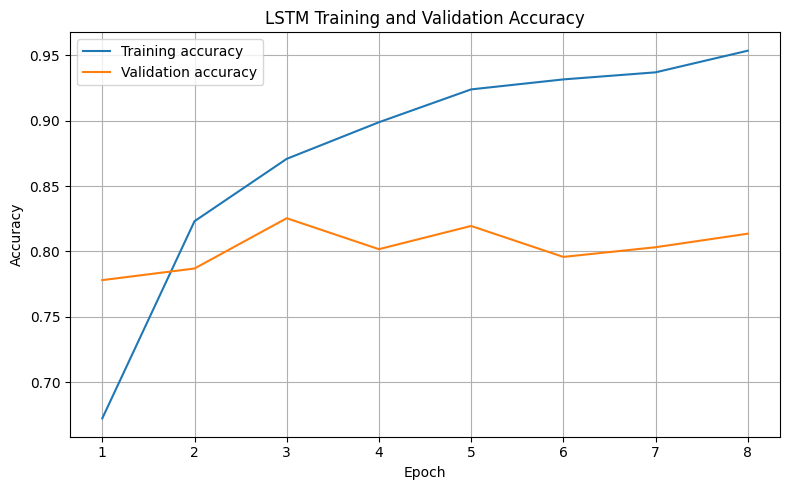

In [293]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    lstm_history["train_accuracy"],
    label="Training accuracy"
)

plt.plot(
    epochs,
    lstm_history["validation_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

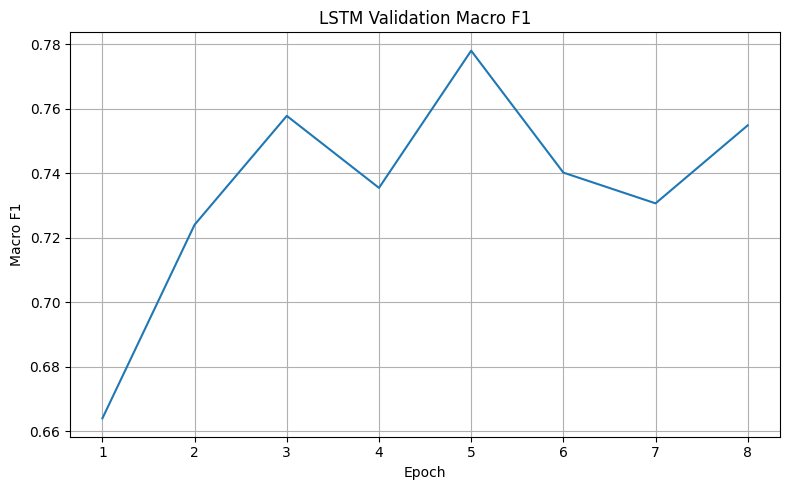

In [294]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    lstm_history["validation_macro_f1"]
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("LSTM Validation Macro F1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [295]:
import pandas as pd

lstm_history_df = pd.DataFrame({
    "Epoch": range(
        1,
        lstm_history["epochs_completed"] + 1
    ),

    "Training Loss": lstm_history[
        "train_loss"
    ],

    "Validation Loss": lstm_history[
        "validation_loss"
    ],

    "Training Accuracy": lstm_history[
        "train_accuracy"
    ],

    "Validation Accuracy": lstm_history[
        "validation_accuracy"
    ],

    "Validation Macro F1": lstm_history[
        "validation_macro_f1"
    ]
})

display(
    lstm_history_df.round(4)
)

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Validation Macro F1
0,1,0.8645,0.5908,0.6724,0.7781,0.6640
1,2,0.5104,0.5363,0.8232,0.7870,0.7241
2,3,0.3664,0.5310,0.8709,0.8254,0.7578
3,4,0.2960,0.5929,0.8989,0.8018,0.7355
4,5,0.2393,0.5782,0.9240,0.8195,0.7781
5,6,0.1934,0.6417,0.9316,0.7959,0.7402
6,7,0.1797,0.7238,0.9370,0.8033,0.7307
7,8,0.1346,0.6855,0.9536,0.8136,0.7549


In [296]:
best_epoch_index = int(
    lstm_history_df["Validation Macro F1"].idxmax()
)

best_epoch_results = lstm_history_df.loc[
    best_epoch_index
]

print("BEST VALIDATION EPOCH")
print("-" * 40)

print(
    "Epoch:",
    int(best_epoch_results["Epoch"])
)

print(
    "Training loss:",
    f"{best_epoch_results['Training Loss']:.4f}"
)

print(
    "Validation loss:",
    f"{best_epoch_results['Validation Loss']:.4f}"
)

print(
    "Training accuracy:",
    f"{best_epoch_results['Training Accuracy']:.4f}"
)

print(
    "Validation accuracy:",
    f"{best_epoch_results['Validation Accuracy']:.4f}"
)

print(
    "Validation macro F1:",
    f"{best_epoch_results['Validation Macro F1']:.4f}"
)

BEST VALIDATION EPOCH
----------------------------------------
Epoch: 5
Training loss: 0.2393
Validation loss: 0.5782
Training accuracy: 0.9240
Validation accuracy: 0.8195
Validation macro F1: 0.7781


##Step 7: Final Evaluation: Evaluate Model Using Test Set and Rigorous Metrics

In [297]:
# RESET TO ORIGINAL DATA FOR A NEW EXPERIMENT

X_train = X_train_all.copy()
y_train = y_train_all.copy()

X_validation = X_validation_all.copy()
y_validation = y_validation_all.copy()

X_test = X_test_all.copy()
y_test = y_test_all.copy()

class_to_idx = original_class_to_idx.copy()
idx_to_class = original_idx_to_class.copy()

In [298]:
# REMOVE CLASSES AFTER FEATURE EXTRACTION

classes_to_remove = [
    "Silk",
    "Fleece",
    "Linen",
    "Satin",
    "Corduroy",
    "Crepe",
    "Viscose",
    "Terrycloth",
]

# Preserve the original mappings before changing them
old_class_to_idx = class_to_idx.copy()
old_idx_to_class = idx_to_class.copy()

labels_to_remove = [
    old_class_to_idx[class_name]
    for class_name in classes_to_remove
    if class_name in old_class_to_idx
]

print("Removing classes:", classes_to_remove)
print("Removing old labels:", labels_to_remove)


# Remove the classes from training data
train_keep_mask = ~np.isin(
    y_train,
    labels_to_remove
)

X_train = X_train[train_keep_mask]
y_train = y_train[train_keep_mask]


# Remove the classes from validation data
if "X_validation" in globals() and "y_validation" in globals():
    validation_keep_mask = ~np.isin(
        y_validation,
        labels_to_remove
    )

    X_validation = X_validation[validation_keep_mask]
    y_validation = y_validation[validation_keep_mask]


# Remove the classes from testing data
test_keep_mask = ~np.isin(
    y_test,
    labels_to_remove
)

X_test = X_test[test_keep_mask]
y_test = y_test[test_keep_mask]


# REMAP THE REMAINING LABELS TO 0, 1, 2, ...

remaining_old_labels = sorted(
    np.unique(y_train).tolist()
)

old_to_new_label = {
    old_label: new_label
    for new_label, old_label in enumerate(
        remaining_old_labels
    )
}


def remap_labels(labels):
    return np.array(
        [
            old_to_new_label[int(label)]
            for label in labels
        ],
        dtype=np.int64
    )


y_train = remap_labels(y_train)
y_test = remap_labels(y_test)

if "y_validation" in globals():
    y_validation = remap_labels(y_validation)


# UPDATE CLASS LIST AND MAPPINGS

all_classes = [
    old_idx_to_class[old_label]
    for old_label in remaining_old_labels
]

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(all_classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}


# VERIFY THE RESULTS

print("\nRemaining classes:")
print(all_classes)

print("\nUpdated class mapping:")
print(class_to_idx)

print("\nTraining features:", X_train.shape)

if "X_validation" in globals():
    print("Validation features:", X_validation.shape)

print("Testing features:", X_test.shape)

print("\nTraining images per remaining class:")

labels, counts = np.unique(
    y_train,
    return_counts=True
)

for label, count in zip(labels, counts):
    print(
        f"{idx_to_class[int(label)]:15s} | "
        f"{count:,}"
    )

Removing classes: ['Silk', 'Fleece', 'Linen', 'Satin', 'Corduroy', 'Crepe', 'Viscose', 'Terrycloth']
Removing old labels: [5, 7, 12, 11, 10, 9, 6, 8]

Remaining classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']

Updated class mapping:
{'Cotton': 0, 'Polyester': 1, 'Denim': 2, 'Wool': 3, 'Nylon': 4}

Training features: (3144, 2048)
Validation features: (676, 2048)
Testing features: (672, 2048)

Training images per remaining class:
Cotton          | 1,648
Polyester       | 632
Denim           | 452
Wool            | 252
Nylon           | 160


In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# FINAL DATASET

X_train_final = X_train
y_train_final = y_train

X_validation_final = X_validation
y_validation_final = y_validation

X_test_final = X_test
y_test_final = y_test

final_classes = mlp_classes

print("Final classes:")
print(final_classes)

print("\nDataset shapes:")
print("Training:", X_train_final.shape, y_train_final.shape)
print("Validation:", X_validation_final.shape, y_validation_final.shape)
print("Testing:", X_test_final.shape, y_test_final.shape)

print("\nLabels present:")
print("Training:", np.unique(y_train_final))
print("Validation:", np.unique(y_validation_final))
print("Testing:", np.unique(y_test_final))

assert len(final_classes) == len(np.unique(y_train_final))
assert X_train_final.shape[0] == len(y_train_final)
assert X_validation_final.shape[0] == len(y_validation_final)
assert X_test_final.shape[0] == len(y_test_final)

Final classes:
['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']

Dataset shapes:
Training: (3144, 2048) (3144,)
Validation: (676, 2048) (676,)
Testing: (672, 2048) (672,)

Labels present:
Training: [0 1 2 3 4]
Validation: [0 1 2 3 4]
Testing: [0 1 2 3 4]


In [300]:
# FINAL MODEL DEFINITIONS

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


final_models = {

    # BASELINE: KNN
    "KNN": make_pipeline(
        StandardScaler(),

        KNeighborsClassifier(
            n_neighbors=5
        )
    ),


    # LINEAR MODEL: LOGISTIC REGRESSION
    "Logistic Regression": make_pipeline(
        StandardScaler(),

        LogisticRegression(
            C=1.0,
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        )
    ),


    # TREE MODEL: RANDOM FOREST
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),


    # NEURAL NETWORK: TUNED MLP
    "MLP": make_pipeline(
        StandardScaler(),

        MLPClassifier(
            # Best parameters from validation tuning
            hidden_layer_sizes=best_mlp_params["hidden_layer_sizes"],

            activation="relu",
            solver="adam",

            learning_rate_init=
                best_mlp_params["learning_rate_init"],

            batch_size=64,

            alpha=
                best_mlp_params["alpha"],

            max_iter=500,

            # Early stopping / regularization
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,

            random_state=SEED
        )
    )
}

print("Final models:")
for model_name in final_models:
    print("-", model_name)

Final models:
- KNN
- Logistic Regression
- Random Forest
- MLP


In [301]:
# TRAIN FINAL MODELS

trained_final_models = {}

for model_name, model in final_models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_final,
        y_train_final
    )

    trained_final_models[model_name] = model

    print(f"{model_name} trained.\n")

Training KNN...
KNN trained.

Training Logistic Regression...
Logistic Regression trained.

Training Random Forest...
Random Forest trained.

Training MLP...
MLP trained.



In [302]:
# VALIDATION CLASSIFICATION REPORTS

for model_name, model in trained_final_models.items():

    predictions = model.predict(
        X_validation_final
    )

    print("\n" + "=" * 60)
    print(f"{model_name} — Validation Classification Report")
    print("=" * 60)

    print(
        classification_report(
            y_validation_final,
            predictions,
            labels=range(len(final_classes)),
            target_names=final_classes,
            zero_division=0
        )
    )


KNN — Validation Classification Report
              precision    recall  f1-score   support

      Cotton       0.75      0.88      0.81       352
   Polyester       0.73      0.54      0.62       136
       Denim       0.71      0.83      0.77        96
        Wool       0.60      0.43      0.50        56
       Nylon       0.88      0.19      0.32        36

    accuracy                           0.73       676
   macro avg       0.73      0.57      0.60       676
weighted avg       0.73      0.73      0.71       676


Logistic Regression — Validation Classification Report
              precision    recall  f1-score   support

      Cotton       0.87      0.80      0.84       352
   Polyester       0.67      0.73      0.70       136
       Denim       0.86      0.95      0.90        96
        Wool       0.71      0.75      0.73        56
       Nylon       0.62      0.69      0.66        36

    accuracy                           0.80       676
   macro avg       0.75      0.78  

In [303]:
# Retrieve fitted MLP from the pipeline
fitted_mlp = trained_final_models[
    "MLP"
].named_steps["mlpclassifier"]

print("MLP TRAINING CONFIGURATION")
print("-" * 45)
print("Loss function: Multiclass log-loss / cross-entropy")
print("Optimizer:", fitted_mlp.solver)
print("Learning rate:", fitted_mlp.learning_rate_init)
print("Batch size:", fitted_mlp.batch_size)
print("Maximum epochs:", fitted_mlp.max_iter)
print("Actual epochs completed:", fitted_mlp.n_iter_)
print("L2 regularization alpha:", fitted_mlp.alpha)
print("Early stopping:", fitted_mlp.early_stopping)
print("Validation fraction:", fitted_mlp.validation_fraction)
print("Patience:", fitted_mlp.n_iter_no_change)

MLP TRAINING CONFIGURATION
---------------------------------------------
Loss function: Multiclass log-loss / cross-entropy
Optimizer: adam
Learning rate: 0.001
Batch size: 64
Maximum epochs: 500
Actual epochs completed: 26
L2 regularization alpha: 0.0001
Early stopping: True
Validation fraction: 0.15
Patience: 15


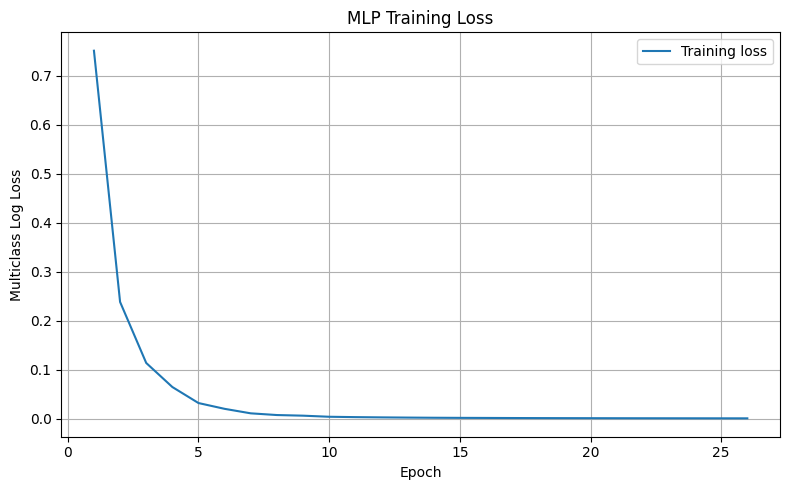

In [304]:
mlp_epochs = range(
    1,
    len(fitted_mlp.loss_curve_) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_epochs,
    fitted_mlp.loss_curve_,
    label="Training loss"
)

plt.xlabel("Epoch")
plt.ylabel("Multiclass Log Loss")
plt.title("MLP Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

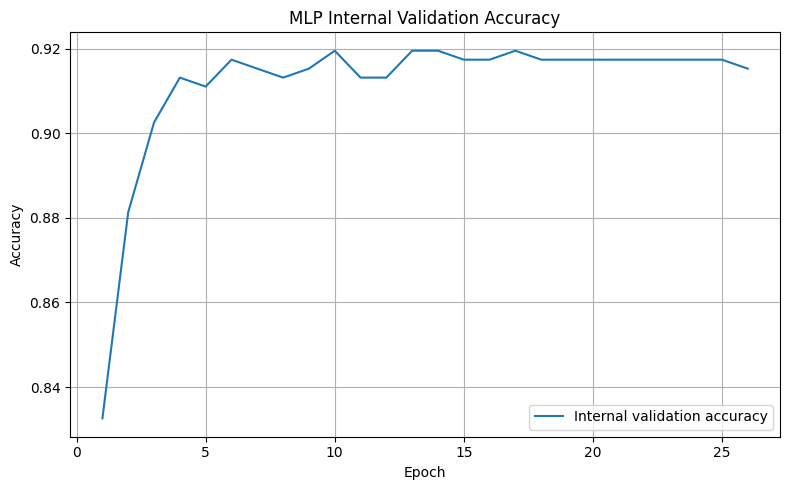

In [305]:
if fitted_mlp.validation_scores_ is not None:

    validation_epochs = range(
        1,
        len(fitted_mlp.validation_scores_) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        validation_epochs,
        fitted_mlp.validation_scores_,
        label="Internal validation accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("MLP Internal Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#final Test Results

In [306]:
# FINAL TEST RESULTS

test_results = []

for model_name, model in trained_final_models.items():

    test_predictions = model.predict(
        X_test_final
    )

    test_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test_final,
            test_predictions
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test_final,
            test_predictions
        ),

        "Macro Precision": precision_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0
        )
    })


test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("FINAL TEST RESULTS")

display(
    test_results_df.round(4)
)

FINAL TEST RESULTS


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,MLP,0.8482,0.7517,0.8038,0.7517,0.7734
1,Logistic Regression,0.8036,0.7303,0.7165,0.7303,0.7221
2,KNN,0.7143,0.5967,0.7457,0.5967,0.6139
3,Random Forest,0.7351,0.5312,0.8825,0.5312,0.5998


###LSTM Model

In [307]:
from sklearn.metrics import classification_report

(
    test_loss,
    test_accuracy,
    test_macro_f1,
    test_targets,
    test_predictions
) = evaluate_lstm(
    lstm_model,
    lstm_test_loader,
    criterion,
    device
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Macro F1: {test_macro_f1:.4f}")

print("\nLSTM Test Classification Report:")

print(
    classification_report(
        test_targets,
        test_predictions,
        labels=range(len(lstm_classes)),
        target_names=lstm_classes,
        zero_division=0
    )
)

Final Test Loss: 0.5281
Final Test Accuracy: 0.8423
Final Test Macro F1: 0.7536

LSTM Test Classification Report:
              precision    recall  f1-score   support

      Cotton       0.84      0.91      0.88       352
   Polyester       0.79      0.79      0.79       136
       Denim       0.87      0.98      0.92       100
        Wool       0.91      0.58      0.71        52
       Nylon       1.00      0.31      0.48        32

    accuracy                           0.84       672
   macro avg       0.88      0.71      0.75       672
weighted avg       0.85      0.84      0.83       672



In [308]:
print("FINAL LSTM TEST RESULTS")
print("-" * 40)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")
print(f"Number of test images: {len(test_targets)}")

FINAL LSTM TEST RESULTS
----------------------------------------
Test loss: 0.5281
Test accuracy: 0.8423
Test macro F1: 0.7536
Number of test images: 672


###Compare Models

In [309]:
print("Classical/MLP classes:", final_classes)
print("LSTM classes:", lstm_classes)

assert list(final_classes) == list(lstm_classes), (
    "The class order is different between the models."
)

print("Class mappings match.")

Classical/MLP classes: ['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']
LSTM classes: ['Cotton', 'Polyester', 'Denim', 'Wool', 'Nylon']
Class mappings match.


In [310]:
import numpy as np

num_classes = len(final_classes)

classical_validation_counts = np.bincount(
    y_validation_final,
    minlength=num_classes
)

lstm_validation_counts = np.bincount(
    y_validation_lstm.numpy()
    if torch.is_tensor(y_validation_lstm)
    else y_validation_lstm,
    minlength=num_classes
)

print("Classical validation counts:")
print(classical_validation_counts)

print("LSTM validation counts:")
print(lstm_validation_counts)

assert np.array_equal(
    classical_validation_counts,
    lstm_validation_counts
), "Validation class counts do not match."

Classical validation counts:
[352 136  96  56  36]
LSTM validation counts:
[352 136  96  56  36]


In [311]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

combined_validation_results = []

# KNN, LOGISTIC REGRESSION, RANDOM FOREST, AND MLP

for model_name, model in trained_final_models.items():

    predictions = model.predict(
        X_validation_final
    )

    combined_validation_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_validation_final,
            predictions
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_validation_final,
            predictions
        ),

        "Macro Precision": precision_score(
            y_validation_final,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_validation_final,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_validation_final,
            predictions,
            average="macro",
            zero_division=0
        )
    })


# ---------------------------------------------------------
# LSTM
# ---------------------------------------------------------

(
    lstm_validation_loss,
    lstm_validation_accuracy,
    lstm_validation_macro_f1,
    lstm_validation_targets,
    lstm_validation_predictions
) = evaluate_lstm(
    lstm_model,
    lstm_validation_loader,
    criterion,
    device
)

combined_validation_results.append({
    "Model": "LSTM",

    "Accuracy": accuracy_score(
        lstm_validation_targets,
        lstm_validation_predictions
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        lstm_validation_targets,
        lstm_validation_predictions
    ),

    "Macro Precision": precision_score(
        lstm_validation_targets,
        lstm_validation_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        lstm_validation_targets,
        lstm_validation_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        lstm_validation_targets,
        lstm_validation_predictions,
        average="macro",
        zero_division=0
    )
})


combined_validation_df = (
    pd.DataFrame(combined_validation_results)
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("COMBINED VALIDATION RESULTS")

display(
    combined_validation_df.round(4)
)

print(
    f"\nLSTM validation cross-entropy loss: "
    f"{lstm_validation_loss:.4f}"
)

COMBINED VALIDATION RESULTS


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,MLP,0.8269,0.7695,0.8004,0.7695,0.7829
1,Logistic Regression,0.7973,0.7843,0.7475,0.7843,0.7644
2,LSTM,0.8254,0.7257,0.8454,0.7257,0.7578
3,KNN,0.7308,0.5748,0.7320,0.5748,0.6021
4,Random Forest,0.7189,0.5260,0.8091,0.5260,0.5797



LSTM validation cross-entropy loss: 0.5310


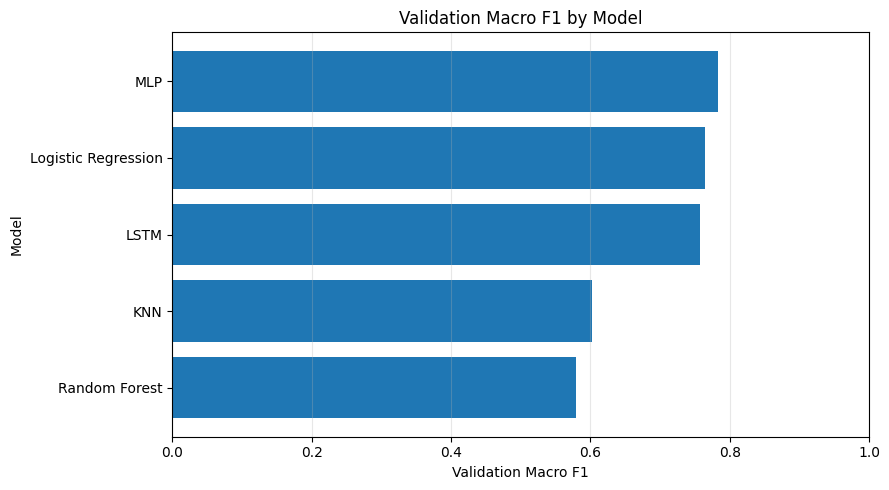

In [312]:
import matplotlib.pyplot as plt

plot_df = combined_validation_df.sort_values(
    "Macro F1",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Model"],
    plot_df["Macro F1"]
)

plt.xlabel("Validation Macro F1")
plt.ylabel("Model")
plt.title("Validation Macro F1 by Model")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [313]:
combined_test_results = []

# ---------------------------------------------------------
# CLASSICAL MODELS AND MLP
# ---------------------------------------------------------

for model_name, model in trained_final_models.items():

    predictions = model.predict(
        X_test_final
    )

    combined_test_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test_final,
            predictions
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test_final,
            predictions
        ),

        "Macro Precision": precision_score(
            y_test_final,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_test_final,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_test_final,
            predictions,
            average="macro",
            zero_division=0
        )
    })


# ---------------------------------------------------------
# LSTM
# ---------------------------------------------------------

(
    lstm_test_loss,
    lstm_test_accuracy,
    lstm_test_macro_f1,
    lstm_test_targets,
    lstm_test_predictions
) = evaluate_lstm(
    lstm_model,
    lstm_test_loader,
    criterion,
    device
)

combined_test_results.append({
    "Model": "LSTM",

    "Accuracy": accuracy_score(
        lstm_test_targets,
        lstm_test_predictions
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        lstm_test_targets,
        lstm_test_predictions
    ),

    "Macro Precision": precision_score(
        lstm_test_targets,
        lstm_test_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        lstm_test_targets,
        lstm_test_predictions,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        lstm_test_targets,
        lstm_test_predictions,
        average="macro",
        zero_division=0
    )
})


combined_test_df = (
    pd.DataFrame(combined_test_results)
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("FINAL COMBINED TEST RESULTS")

display(
    combined_test_df.round(4)
)

print(
    f"\nLSTM test cross-entropy loss: "
    f"{lstm_test_loss:.4f}"
)

FINAL COMBINED TEST RESULTS


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,MLP,0.8482,0.7517,0.8038,0.7517,0.7734
1,LSTM,0.8423,0.7136,0.8823,0.7136,0.7536
2,Logistic Regression,0.8036,0.7303,0.7165,0.7303,0.7221
3,KNN,0.7143,0.5967,0.7457,0.5967,0.6139
4,Random Forest,0.7351,0.5312,0.8825,0.5312,0.5998



LSTM test cross-entropy loss: 0.5281


In [314]:
# GET LSTM TEST PROBABILITIES

def get_lstm_probabilities(model, data_loader, device):

    model.eval()

    all_targets = []
    all_probabilities = []

    with torch.inference_mode():

        for features, labels in data_loader:

            features = features.to(
                device,
                dtype=torch.float32
            )

            logits = model(features)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

            all_targets.append(
                labels.numpy()
            )

    all_targets = np.concatenate(all_targets)

    all_probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    all_predictions = np.argmax(
        all_probabilities,
        axis=1
    )

    return (
        all_targets,
        all_predictions,
        all_probabilities
    )


(
    lstm_test_targets,
    lstm_test_predictions,
    lstm_test_probabilities
) = get_lstm_probabilities(
    lstm_model,
    lstm_test_loader,
    device
)

In [315]:
# ---------------------------------------------------------
# ROC-AUC FOR ALL FINAL MODELS
# ---------------------------------------------------------

from sklearn.metrics import roc_auc_score

roc_auc_results = []

test_predictions_by_model = {}
test_probabilities_by_model = {}
test_targets_by_model = {}


# sklearn models
for model_name, model in trained_final_models.items():

    predictions = model.predict(
        X_test_final
    )

    probabilities = model.predict_proba(
        X_test_final
    )

    macro_auc = roc_auc_score(
        y_test_final,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    weighted_auc = roc_auc_score(
        y_test_final,
        probabilities,
        multi_class="ovr",
        average="weighted"
    )

    roc_auc_results.append({
        "Model": model_name,
        "Macro ROC-AUC": macro_auc,
        "Weighted ROC-AUC": weighted_auc
    })

    test_targets_by_model[model_name] = y_test_final
    test_predictions_by_model[model_name] = predictions
    test_probabilities_by_model[model_name] = probabilities


# LSTM
lstm_macro_auc = roc_auc_score(
    lstm_test_targets,
    lstm_test_probabilities,
    multi_class="ovr",
    average="macro"
)

lstm_weighted_auc = roc_auc_score(
    lstm_test_targets,
    lstm_test_probabilities,
    multi_class="ovr",
    average="weighted"
)

roc_auc_results.append({
    "Model": "LSTM",
    "Macro ROC-AUC": lstm_macro_auc,
    "Weighted ROC-AUC": lstm_weighted_auc
})

test_targets_by_model["LSTM"] = lstm_test_targets
test_predictions_by_model["LSTM"] = lstm_test_predictions
test_probabilities_by_model["LSTM"] = lstm_test_probabilities


roc_auc_df = pd.DataFrame(
    roc_auc_results
)

display(
    roc_auc_df.round(4)
)

,Model,Macro ROC-AUC,Weighted ROC-AUC
0,KNN,0.8627,0.8571
1,Logistic Regression,0.9304,0.9192
2,Random Forest,0.9428,0.9416
3,MLP,0.9584,0.9568
4,LSTM,0.9469,0.9492


In [316]:
combined_test_df = combined_test_df.merge(
    roc_auc_df,
    on="Model"
)

print("FINAL TEST RESULTS WITH ROC-AUC")

display(
    combined_test_df.round(4)
)

FINAL TEST RESULTS WITH ROC-AUC


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC,Weighted ROC-AUC
0,MLP,0.8482,0.7517,0.8038,0.7517,0.7734,0.9584,0.9568
1,LSTM,0.8423,0.7136,0.8823,0.7136,0.7536,0.9469,0.9492
2,Logistic Regression,0.8036,0.7303,0.7165,0.7303,0.7221,0.9304,0.9192
3,KNN,0.7143,0.5967,0.7457,0.5967,0.6139,0.8627,0.8571
4,Random Forest,0.7351,0.5312,0.8825,0.5312,0.5998,0.9428,0.9416


Best model selected using validation Macro F1: MLP


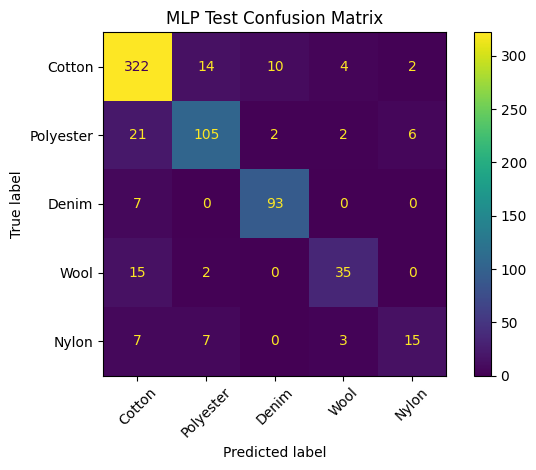

In [317]:
# CONFUSION MATRIX FOR VALIDATION-SELECTED BEST MODEL

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = combined_validation_df.iloc[0]["Model"]

print(
    "Best model selected using validation Macro F1:",
    best_model_name
)

best_test_targets = test_targets_by_model[
    best_model_name
]

best_test_predictions = test_predictions_by_model[
    best_model_name
]

ConfusionMatrixDisplay.from_predictions(
    best_test_targets,
    best_test_predictions,
    labels=range(len(final_classes)),
    display_labels=final_classes,
    xticks_rotation=45
)

plt.title(
    f"{best_model_name} Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

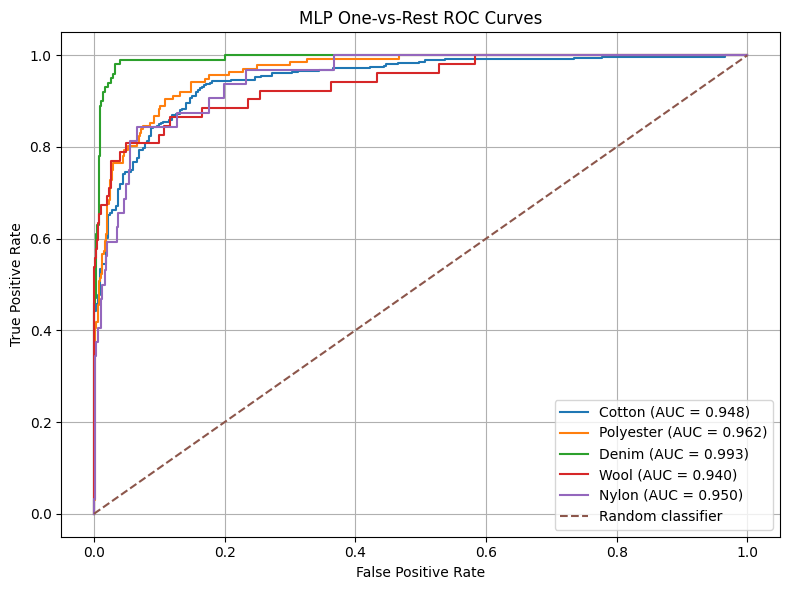

In [318]:
# ---------------------------------------------------------
# ROC CURVES FOR VALIDATION-SELECTED BEST MODEL
# ---------------------------------------------------------

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

best_test_probabilities = test_probabilities_by_model[
    best_model_name
]

y_test_binary = label_binarize(
    best_test_targets,
    classes=range(len(final_classes))
)

plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(
    final_classes
):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, class_index],
        best_test_probabilities[:, class_index]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{class_name} "
            f"(AUC = {class_auc:.3f})"
        )
    )


# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"{best_model_name} One-vs-Rest ROC Curves"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()